In [1]:
import json, math, shutil
from pathlib import Path

import cv2
import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

# ── font (English only in plots) ──
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.unicode_minus': False,
    'figure.dpi': 100,
})

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

CAPTURES_DIR = Path('/home/vsc/LLM_TUNE/AIC_Sejong/aic_data/captures')
VIEWS = ['left', 'center', 'right']

ALL_SESSIONS = sorted([
    p for p in CAPTURES_DIR.iterdir()
    if p.is_dir() and (p / 'steps.jsonl').exists()
])

def parse_session(d: Path) -> dict:
    parts = d.name.split('_')
    return {'session': d.name, 'task_type': parts[2], 'rail': parts[3], 'session_dir': d}

print(f'{len(ALL_SESSIONS)} valid sessions')

56 valid sessions


## Section 1-1 — 데이터 파싱 (steps.jsonl)

### 무엇을 보는가
각 에피소드 디렉토리의 `steps.jsonl`을 읽어 하나의 DataFrame으로 합칩니다.  
행 1개 = 스텝 1개이며, 이후 모든 분석의 입력이 됩니다.

### 어떻게 판단하는가
- **Total steps 수**: 세션 수 × 평균 스텝 수가 예상 범위인지 확인.  
  스텝이 비정상적으로 적은 세션은 도중 종료된 에피소드일 가능성이 있습니다.
- **컬럼 결측 확인**: `tip_x_error`, `plug_x` 등 핵심 컬럼에 NaN이 많으면  
  해당 필드가 기록되지 않은 세션이 섞인 것이므로 필터링이 필요합니다.

In [2]:
# ── 1-1: Parse steps.jsonl ───────────────────────────────────────────────────
step_rows = []
for sess_dir in tqdm(ALL_SESSIONS, desc='Parsing steps'):
    info = parse_session(sess_dir)
    with open(sess_dir / 'steps.jsonl') as f:
        for line in f:
            d = json.loads(line)
            obs    = d.get('observation', {})
            ext    = d.get('extras', {})
            tfm    = d.get('transforms', {})
            wrench = obs.get('wrist_wrench', {})
            force  = wrench.get('force', {})
            torque = wrench.get('torque', {})
            ctrl   = obs.get('controller_state', {})
            plug_t = tfm.get('plug', {}).get('translation', {})
            plug_r = tfm.get('plug', {}).get('rotation', {})     # NEW: quaternion
            port_t = tfm.get('port', {}).get('translation', {})
            grip_t = tfm.get('gripper', {}).get('translation', {})  # NEW
            grip_r = tfm.get('gripper', {}).get('rotation', {})     # NEW
            step_rows.append({
                'session':    info['session'],
                'task_type':  info['task_type'],
                'rail':       info['rail'],
                'step':       d['step'],
                'phase':      d['phase'],
                'tip_x_error': ext.get('tip_x_error'),
                'tip_y_error': ext.get('tip_y_error'),
                'z_offset':   ext.get('z_offset'),
                'force_x': force.get('x'), 'force_y': force.get('y'), 'force_z': force.get('z'),
                'torque_x': torque.get('x'), 'torque_y': torque.get('y'), 'torque_z': torque.get('z'),
                # plug world pose
                'plug_x': plug_t.get('x'), 'plug_y': plug_t.get('y'), 'plug_z': plug_t.get('z'),
                'plug_qw': plug_r.get('w'), 'plug_qx': plug_r.get('x'),
                'plug_qy': plug_r.get('y'), 'plug_qz': plug_r.get('z'),
                # port world pose
                'port_x': port_t.get('x'), 'port_y': port_t.get('y'), 'port_z': port_t.get('z'),
                # gripper world pose
                'grip_x': grip_t.get('x'), 'grip_y': grip_t.get('y'), 'grip_z': grip_t.get('z'),
                'grip_qw': grip_r.get('w'), 'grip_qx': grip_r.get('x'),
                'grip_qy': grip_r.get('y'), 'grip_qz': grip_r.get('z'),
            })

steps_df = pd.DataFrame(step_rows)
print(f'Total steps: {len(steps_df):,}')

Parsing steps:   0%|          | 0/56 [00:00<?, ?it/s]

Total steps: 29,736


## Section 1-2 — Phase & Task 분포 불균형

### 무엇을 보는가
전체 스텝 수를 phase(approach / insert / stabilize)와 task_type(nic / sc)으로 나누어  
각 카테고리가 데이터셋에서 차지하는 비율을 시각화합니다.

### 어떻게 판단하는가
| 확인 항목 | 판단 기준 | 대응 |
|-----------|----------|------|
| insert 비율 | > 60% → 인코더가 insert 외관에 과도하게 특화됨 | approach 오버샘플링 |
| nic : sc 비율 | 70:30 이상 치우침 → 배치에서 특정 태스크 지배 | 배치 내 1:1 샘플링 |
| stabilize 비율 | 매우 낮음 → 학습 시 무시해도 됨 | 별도 처리 불필요 |

**핵심 메시지**: 불균형한 phase/task 분포는 인코더가 "삽입 직전 자세"에만 최적화되고  
approach 구간(로봇이 이동하는 다양한 시각 정보)을 제대로 학습하지 못하는 원인이 됩니다.

In [3]:
display(steps_df.head(10))

,session,task_type,rail,step,phase,tip_x_error,tip_y_error,z_offset,force_x,force_y,force_z,torque_x,torque_y,torque_z,plug_x,plug_y,plug_z,plug_qw,plug_qx,plug_qy,plug_qz,port_x,port_y,port_z,grip_x,grip_y,grip_z,grip_qw,grip_qx,grip_qy,grip_qz
0,20260418_131831_nic_rail0_task_1,nic,rail0,0,approach,-0.062664,0.007720,0.2,0.127637,0.445452,20.933467,0.095136,-0.167814,0.028352,-0.372859,0.214537,0.265077,-0.177837,0.983665,0.027414,0.005043,-0.435524,0.222257,0.133476,-0.372858,0.193851,0.319197,-0.000021,-1.000000,-0.000031,-0.000011
1,20260418_131831_nic_rail0_task_1,nic,rail0,1,approach,-0.062426,0.007680,0.2,-0.375061,0.946422,24.860733,0.035943,-0.174809,0.094970,-0.373098,0.214577,0.266469,-0.177965,0.983645,0.027352,0.004731,-0.435524,0.222257,0.133476,-0.373062,0.193878,0.320584,-0.000101,1.000000,0.000026,-0.000311
2,20260418_131831_nic_rail0_task_1,nic,rail0,2,approach,-0.062715,0.007306,0.2,-0.638627,0.657248,22.100220,0.090180,-0.064396,0.124854,-0.372809,0.214951,0.287859,-0.178257,0.983605,0.027066,0.003515,-0.435524,0.222257,0.133476,-0.372657,0.194221,0.341465,-0.000365,0.999999,-0.000033,-0.001546
3,20260418_131831_nic_rail0_task_1,nic,rail0,3,approach,-0.064592,0.007377,0.2,-0.784697,0.567802,21.110592,0.069019,-0.095840,0.071852,-0.370932,0.214880,0.326087,-0.177945,0.983675,0.026673,0.002685,-0.435524,0.222257,0.133476,-0.370644,0.194185,0.380810,0.000011,-0.999997,0.000285,0.002459
4,20260418_131831_nic_rail0_task_1,nic,rail0,4,approach,-0.066998,0.007574,0.2,-1.319506,0.218972,20.760973,0.053058,0.160000,0.000425,-0.368526,0.214683,0.371471,-0.177114,0.983844,0.026027,0.001835,-0.435524,0.222257,0.133476,-0.368189,0.194086,0.425623,-0.000845,-0.999994,0.000772,0.003373
5,20260418_131831_nic_rail0_task_1,nic,rail0,5,approach,-0.069070,0.007740,0.2,-1.536055,0.561632,20.109901,-0.094816,0.339004,0.079882,-0.366454,0.214517,0.408638,-0.175983,0.984065,0.025376,0.001192,-0.435524,0.222257,0.133476,-0.366062,0.194047,0.462837,-0.002011,-0.999989,0.001309,0.004092
6,20260418_131831_nic_rail0_task_1,nic,rail0,6,approach,-0.071535,0.008051,0.2,-1.698047,0.244362,19.580496,-0.071616,0.446626,-0.005041,-0.363989,0.214206,0.448388,-0.174277,0.984393,0.024459,0.000385,-0.435524,0.222257,0.133476,-0.363528,0.193925,0.502658,0.003765,0.999978,-0.002086,-0.005003
7,20260418_131831_nic_rail0_task_1,nic,rail0,7,approach,-0.074225,0.008418,0.2,-2.169226,-0.182698,19.471691,-0.154836,0.707501,0.010436,-0.361299,0.213839,0.484272,-0.172353,0.984755,0.023472,-0.000387,-0.435524,0.222257,0.133476,-0.360733,0.193767,0.539152,0.005775,0.999962,-0.002954,-0.005907
8,20260418_131831_nic_rail0_task_1,nic,rail0,8,approach,-0.077491,0.009096,0.2,-2.379778,-0.702598,18.165733,-0.201400,1.185778,0.044162,-0.358033,0.213161,0.518585,-0.169950,0.985200,0.022248,-0.001448,-0.435524,0.222257,0.133476,-0.357365,0.193349,0.573524,0.008247,0.999933,-0.003997,-0.007108
9,20260418_131831_nic_rail0_task_1,nic,rail0,9,approach,-0.081671,0.010352,0.2,-2.438366,-0.903489,17.080464,-0.358461,1.419452,0.058220,-0.353853,0.211905,0.550107,-0.167267,0.985688,0.020752,-0.003055,-0.435524,0.222257,0.133476,-0.353095,0.192405,0.604655,0.010967,0.999887,-0.005191,-0.008861


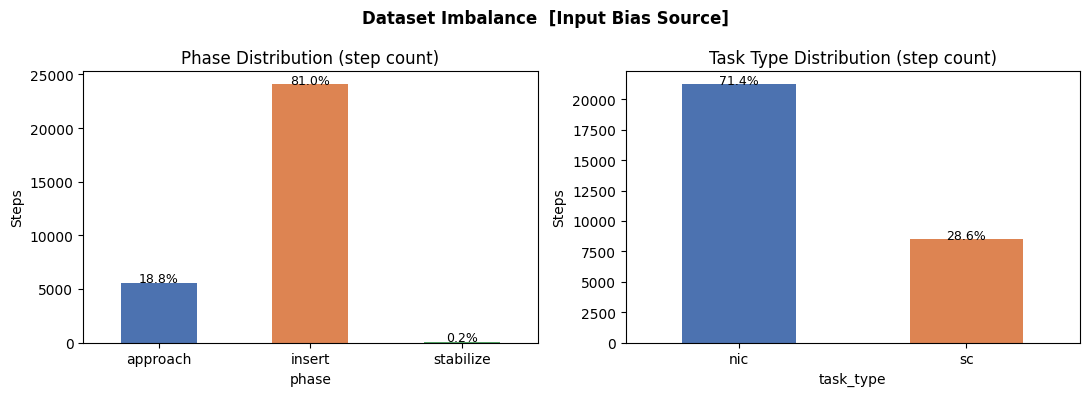


[Bias] insert dominates: 81% of all frames
[Bias] nic dominates: 71% of all frames


In [4]:

# ── 1-2: Phase & Task imbalance ──────────────────────────────────────────────
phase_cnt  = steps_df['phase'].value_counts().reindex(['approach','insert','stabilize'])
task_cnt   = steps_df['task_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

phase_cnt.plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868'], rot=0)
for bar, v in zip(axes[0].patches, phase_cnt):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{v/phase_cnt.sum()*100:.1f}%', ha='center', fontsize=9)
axes[0].set_title('Phase Distribution (step count)')
axes[0].set_ylabel('Steps')

task_cnt.plot(kind='bar', ax=axes[1], color=['#4C72B0','#DD8452'], rot=0)
for bar, v in zip(axes[1].patches, task_cnt):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{v/task_cnt.sum()*100:.1f}%', ha='center', fontsize=9)
axes[1].set_title('Task Type Distribution (step count)')
axes[1].set_ylabel('Steps')

plt.suptitle('Dataset Imbalance  [Input Bias Source]', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n[Bias] insert dominates: {:.0f}% of all frames'.format(
    phase_cnt['insert']/phase_cnt.sum()*100))
print('[Bias] nic dominates: {:.0f}% of all frames'.format(
    task_cnt['nic']/task_cnt.sum()*100))

## Section 2-1 — Tip Error 분포 (Output Space Bias)

### 무엇을 보는가
`tip_x_error` / `tip_y_error` = 포트 위치 - 플러그 위치 (월드 프레임, 미터 단위).  
이 값이 0에 수렴하면 삽입 성공입니다.  
**Approach와 Insert 두 위상 모두**의 오차 분포와 시간적 변화를 함께 봅니다.

### 어떻게 판단하는가

**2D Scatter (approach / insert 각각)**
- **Approach scatter**: 로봇은 항상 고정된 자세 (랜덤이 아닌 포즈)로 스폰된다고 하니, 원점에서 멀리 퍼져있으면 안됨
- **Insert scatter**: 원점 주변에 집중되는 패턴이 정상. 원점에서 멀리 퍼져 있으면  
  삽입 실패 에피소드가 포함된 것.

**수렴 궤적 (approach / insert 각각)**
| 위상 | 정상 패턴 | 이상 신호 |
|------|----------|-----------|
| Approach | `|tip_error|`가 감소 추세 (포트에 접근 중) | 평탄 또는 증가 → 잘못된 궤적 |
| Insert | 0을 향해 단조 감소 | 수렴 없이 진동 → 비수렴 케이스 |

**비수렴 케이스(Insert에서 `|tip_error|`가 줄지 않는 궤적)는 제거 대상이 아닙니다.**  
완벽하게 수렴하는 케이스만 남기면 인코더는 '항상 잘 되는 상황'만 학습하게 됩니다.  
비수렴 케이스는 **어려운 시작 조건·접촉 실패 복구 상황**에 대한 정보를 담고 있어  
정책의 강건성(robustness)을 높이는 데 필수적입니다.  
단, **완전 실패**(tip_error가 전혀 줄지 않고 time_limit까지 발산)는 레이블 품질을 떨어뜨리므로  
별도 플래그를 달아두고 학습 비중을 조절하는 전략이 유효합니다.

**평균 bias (mean_x, mean_y)**
| 조건 | 의미 | 대응 |
|------|------|------|
| `|mean| < std × 0.3` | 오차 분포가 대칭 → 출력 편향 없음 (OK) | 별도 처리 불필요 |
| `|mean| > std × 0.3` | 특정 방향으로 치우침 → 출력 공간 편향 (BIASED) | 삽입 시작 시 Gaussian XY offset 추가로 다양화 |

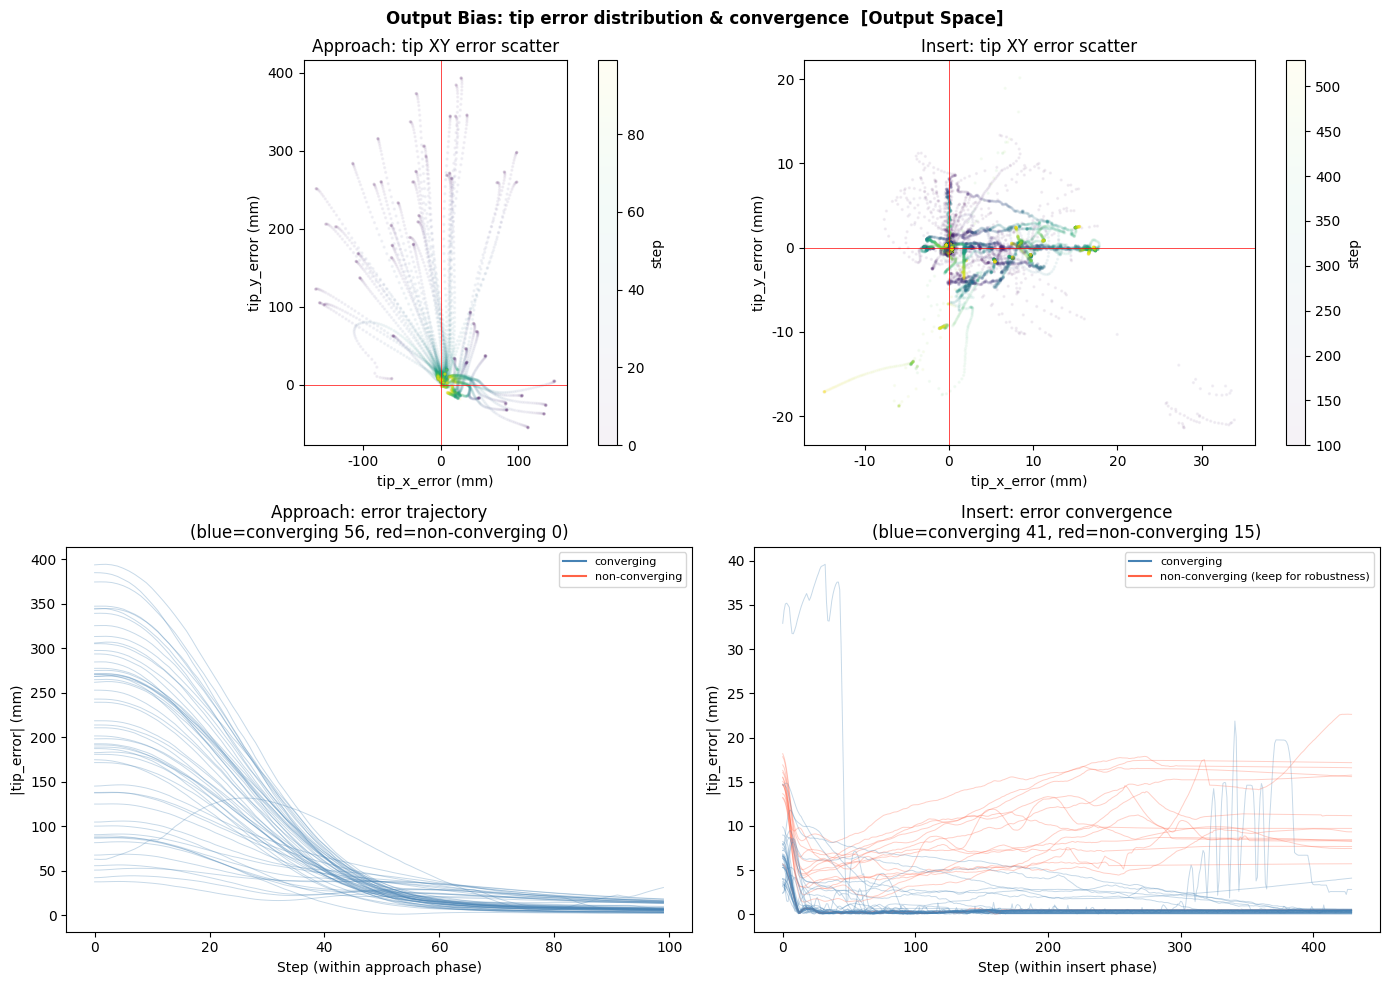

tip_error stats (insert phase):


tip_x_error                                                                tip_y_error                                                               
                count     mean      std      min      25%      50%      75%      max       count     mean      std      min      25%      50%      75%      max
task_type                                                                                                                                                      
nic           17200.0  0.00017  0.00183 -0.00768 -0.00008  0.00009  0.00024  0.03390     17200.0  0.00019  0.00174 -0.02139 -0.00011  0.00008  0.00032  0.02018
sc             6880.0  0.00740  0.00530 -0.01481  0.00287  0.00757  0.01060  0.01786      6880.0 -0.00097  0.00328 -0.01748 -0.00192 -0.00024  0.00054  0.01000


Approach: converging 56/56 (100.0%),  non-converging 0/56 (0.0%)
Insert  : converging 41/56 (73.2%),  non-converging 15/56 (26.8%)  ← keep for robustness


In [5]:
# ── 2-1: tip_error 2D scatter + convergence (approach & insert) ────────────
# tip_x/y_error = port.xy - plug.xy  (world frame, metres)
# I-controller converges these to 0 → distribution biased toward 0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── (a) Approach 2D scatter ────────────────────────────────────────────────
ax = axes[0, 0]
sub = steps_df[steps_df['phase'] == 'approach']
sc = ax.scatter(sub['tip_x_error']*1000, sub['tip_y_error']*1000,
               alpha=0.05, s=2, c=sub['step'], cmap='viridis')
ax.axhline(0, color='red', lw=0.5); ax.axvline(0, color='red', lw=0.5)
ax.set_xlabel('tip_x_error (mm)'); ax.set_ylabel('tip_y_error (mm)')
ax.set_title('Approach: tip XY error scatter')
ax.set_aspect('equal')
plt.colorbar(sc, ax=ax, label='step')

# ── (b) Insert 2D scatter ──────────────────────────────────────────────────
ax = axes[0, 1]
sub = steps_df[steps_df['phase'] == 'insert']
sc = ax.scatter(sub['tip_x_error']*1000, sub['tip_y_error']*1000,
               alpha=0.05, s=2, c=sub['step'], cmap='viridis')
ax.axhline(0, color='red', lw=0.5); ax.axvline(0, color='red', lw=0.5)
ax.set_xlabel('tip_x_error (mm)'); ax.set_ylabel('tip_y_error (mm)')
ax.set_title('Insert: tip XY error scatter')
ax.set_aspect('equal')
plt.colorbar(sc, ax=ax, label='step')

# ── (c) Approach 수렴 궤적 ────────────────────────────────────────────────
ax = axes[1, 0]
converging_app, nonconverging_app = 0, 0
for sess, sg in steps_df[steps_df['phase'] == 'approach'].groupby('session'):
    err_mag = np.sqrt(sg['tip_x_error']**2 + sg['tip_y_error']**2) * 1000
    steps_rel = sg['step'] - sg['step'].min()
    # 수렴 판정: 후반부 평균 < 전반부 평균
    mid = len(err_mag) // 2
    if mid > 0:
        is_conv = err_mag.iloc[mid:].mean() < err_mag.iloc[:mid].mean()
        color = 'steelblue' if is_conv else 'tomato'
        if is_conv: converging_app += 1
        else: nonconverging_app += 1
    else:
        color = 'steelblue'
    ax.plot(steps_rel, err_mag, alpha=0.3, lw=0.7, color=color)
ax.set_xlabel('Step (within approach phase)')
ax.set_ylabel('|tip_error| (mm)')
ax.set_title(f'Approach: error trajectory\n'
             f'(blue=converging {converging_app}, red=non-converging {nonconverging_app})')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color='steelblue', lw=1.5, label='converging'),
    Line2D([0],[0], color='tomato',    lw=1.5, label='non-converging'),
], fontsize=8)

# ── (d) Insert 수렴 궤적 ─────────────────────────────────────────────────
ax = axes[1, 1]
converging_ins, nonconverging_ins = 0, 0
for sess, sg in steps_df[steps_df['phase'] == 'insert'].groupby('session'):
    err_mag = np.sqrt(sg['tip_x_error']**2 + sg['tip_y_error']**2) * 1000
    steps_rel = sg['step'] - sg['step'].min()
    mid = len(err_mag) // 2
    if mid > 0:
        is_conv = err_mag.iloc[mid:].mean() < err_mag.iloc[:mid].mean()
        color = 'steelblue' if is_conv else 'tomato'
        if is_conv: converging_ins += 1
        else: nonconverging_ins += 1
    else:
        color = 'steelblue'
    ax.plot(steps_rel, err_mag, alpha=0.3, lw=0.7, color=color)
ax.set_xlabel('Step (within insert phase)')
ax.set_ylabel('|tip_error| (mm)')
ax.set_title(f'Insert: error convergence\n'
             f'(blue=converging {converging_ins}, red=non-converging {nonconverging_ins})')
ax.legend(handles=[
    Line2D([0],[0], color='steelblue', lw=1.5, label='converging'),
    Line2D([0],[0], color='tomato',    lw=1.5, label='non-converging (keep for robustness)'),
], fontsize=8)

plt.suptitle('Output Bias: tip error distribution & convergence  [Output Space]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 통계 요약 ─────────────────────────────────────────────────────────────
ins = steps_df[steps_df['phase'] == 'insert']
print('tip_error stats (insert phase):')
display(ins.groupby('task_type')[['tip_x_error','tip_y_error']].describe().round(5))

total_ins = converging_ins + nonconverging_ins
total_app = converging_app + nonconverging_app
print(f'\nApproach: converging {converging_app}/{total_app} '
      f'({converging_app/max(1,total_app)*100:.1f}%),  '
      f'non-converging {nonconverging_app}/{total_app} '
      f'({nonconverging_app/max(1,total_app)*100:.1f}%)')
print(f'Insert  : converging {converging_ins}/{total_ins} '
      f'({converging_ins/max(1,total_ins)*100:.1f}%),  '
      f'non-converging {nonconverging_ins}/{total_ins} '
      f'({nonconverging_ins/max(1,total_ins)*100:.1f}%)  ← keep for robustness')

## Section 2-2 — z_offset 궤적 & Force XYZ 분포
Z
### 무엇을 보는가
- `z_offset`: 플러그가 포트 삽입 방향으로 얼마나 이동했는지 (미터).
- `force_x/y/z`: 손목 F/T 센서(ATI AXIA80-M20)가 측정한 3축 접촉력 (뉴턴).
  - `force_z`: 삽입 방향 힘 — 접촉 여부의 주 지표
  - `force_x/y`: 측면 힘 — 정렬 오차 또는 케이블 장력의 지표

### 어떻게 판단하는가

**z_offset 궤적**
- 모든 세션이 비슷한 궤적 → z_offset 다양성 없음 → 인코더가 깊이를 암기할 수 있음.
- 세션마다 다른 형태 → 다양한 삽입 전략 존재 → 좋음.
- 완전히 평탄한 궤적(z_offset 변화 없음) → 삽입 실패 에피소드 의심.

**Force XYZ by phase**
| 축 | approach 정상 | insert 정상 | 이상 신호 |
|----|--------------|------------|----------|
| force_z | ≈ 0 (미접촉) | 양수, 분포 넓음 (다양한 접촉력) | 항상 0 → Tare 오류 / 접촉 실패 |
| force_x | ≈ 0 | 소폭 분포 (케이블 무게·장력) | 큰 값 → 심한 측면 충돌 |
| force_y | ≈ 0 | 소폭 분포 | 큰 값 → 심한 측면 충돌 |

**force_x/y의 추가 의미:**  
삽입 방향(z)과 달리 x/y 방향 힘은 플러그가 **정렬되지 않은 채 포트 측면을 긁는** 상황에서 발생합니다.  
- approach에서 force_x/y가 크면 → 케이블 장력이 그리퍼를 당기는 중 (케이블 루팅 문제)
- insert에서 force_x/y std가 force_z std보다 훨씬 크면 → 정렬 실패 에피소드 다수 포함
- `force_z < 0` (당기는 힘) → 역삽입 또는 플러그가 포트에서 빠지는 중 → 필터링 검토

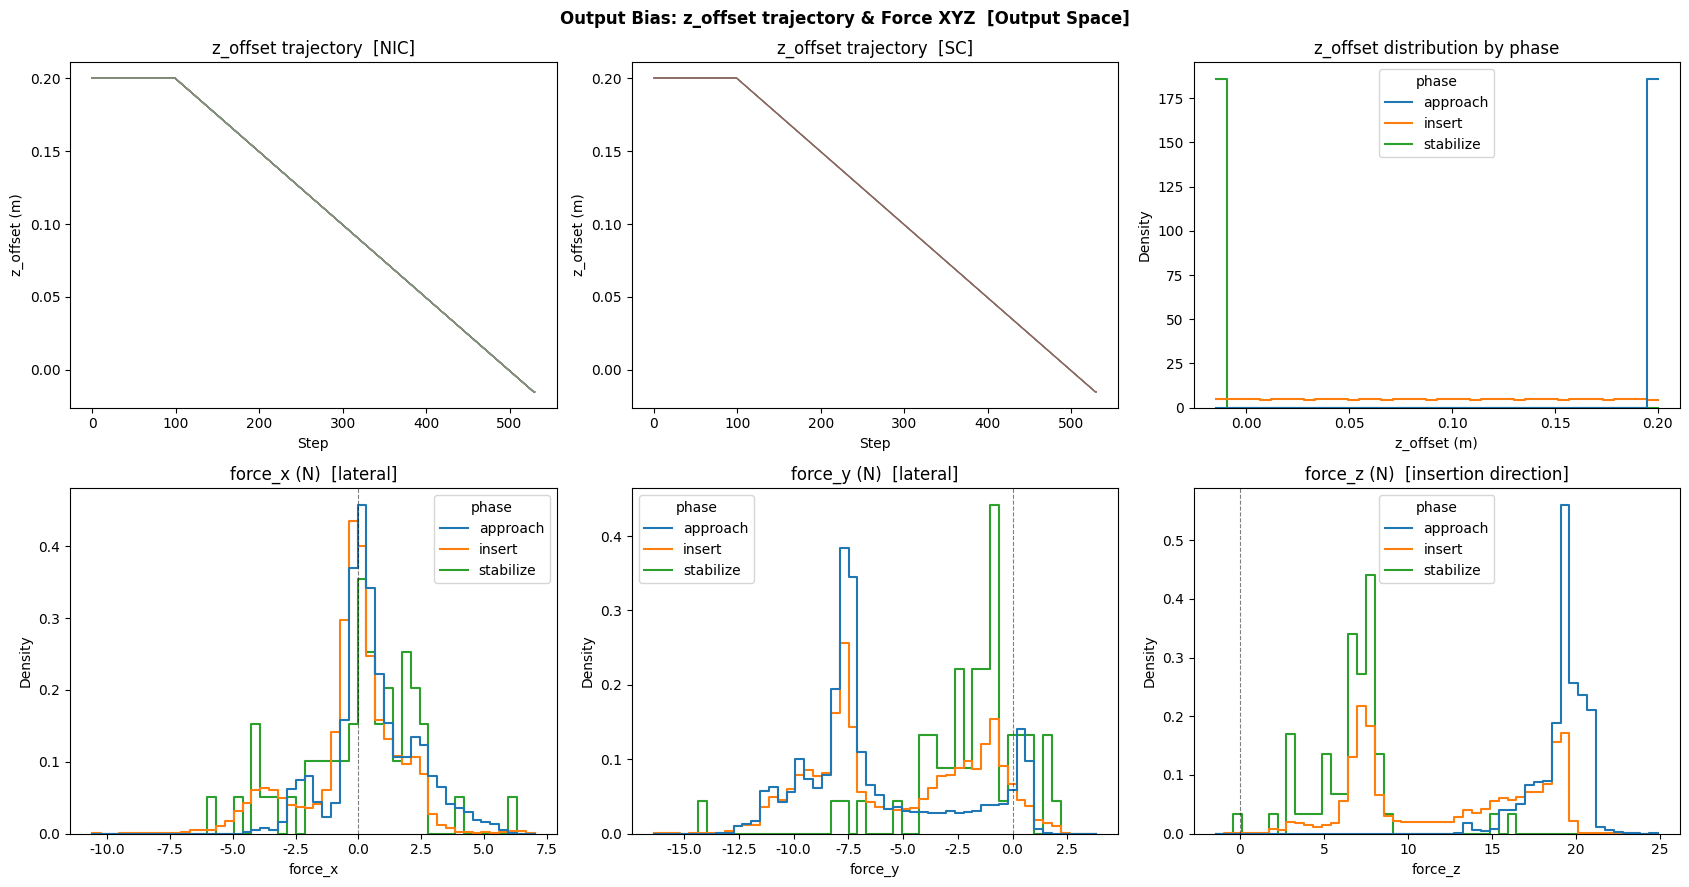

Force stats by phase:


force_x                                                           force_y                                                           force_z                            \
             count    mean     std      min     25%     50%     75%     max    count    mean     std      min     25%     50%     75%     max    count     mean     std      min   
phase                                                                                                                                                                              
approach    5600.0  0.6438  1.6575  -4.5306 -0.1789  0.3872  1.5736  6.1544   5600.0 -6.2362  3.4980 -13.3058 -8.1850 -7.4167 -4.1860  1.4821   5600.0  19.1563  1.4426  12.8445   
insert     24080.0 -0.2565  1.8876 -10.5982 -0.7413 -0.0517  0.7459  7.0101  24080.0 -5.2419  3.6893 -16.3751 -8.0921 -5.9870 -1.7085  3.8203  24080.0  12.4302  5.2828  -1.4460   
stabilize     56.0  0.0700  2.2758  -5.9811 -0.9281  0.3780  1.5538  6.0269     56.0 -1.8900  2.6987 -14.0350 -2.7278 -1.3968 -0.5482  1.9945     56.0   6.6461  2.5399  -0.0434   

                                               
               25%      50%      75%      max  
phase                                          
approach   18.7704  19.3902  20.1020  24.8607  
insert      7.4103  13.0696  17.7567  23.1831  
stabilize   5.5872   6.9712   7.7203  15.9331

  std(force_x) / std(force_z) = 0.357  [OK]
  std(force_y) / std(force_z) = 0.698  [HIGH lateral force — alignment issues likely]


In [6]:
# ── 2-2: z_offset trajectory & Force XYZ distribution ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# ── (row 0) z_offset 궤적: NIC / SC / 전체 통계 ─────────────────────────────
for task, ax in zip(['nic', 'sc'], axes[0, :2]):
    for sess, sg in steps_df[steps_df['task_type'] == task].groupby('session'):
        ax.plot(sg['step'], sg['z_offset'], alpha=0.35, lw=0.8)
    ax.set_xlabel('Step')
    ax.set_ylabel('z_offset (m)')
    ax.set_title(f'z_offset trajectory  [{task.upper()}]')

# z_offset by phase (insert만 분포 비교)
sns.histplot(data=steps_df, x='z_offset', hue='phase', bins=40,
             stat='density', common_norm=False, element='step',
             fill=False, ax=axes[0, 2])
axes[0, 2].set_title('z_offset distribution by phase')
axes[0, 2].set_xlabel('z_offset (m)')

# ── (row 1) Force x / y / z by phase ────────────────────────────────────────
force_cols = ['force_x', 'force_y', 'force_z']
force_labels = ['force_x (N)  [lateral]',
                'force_y (N)  [lateral]',
                'force_z (N)  [insertion direction]']

for ax, col, label in zip(axes[1], force_cols, force_labels):
    sns.histplot(data=steps_df, x=col, hue='phase', bins=50,
                 stat='density', common_norm=False, element='step',
                 fill=False, ax=ax)
    ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(label)
    ax.set_xlabel(col)

plt.suptitle('Output Bias: z_offset trajectory & Force XYZ  [Output Space]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Force 통계 요약 ───────────────────────────────────────────────────────────
print('Force stats by phase:')
display(
    steps_df.groupby('phase')[['force_x','force_y','force_z']]
    .describe().round(4)
)

# 측면력 vs 삽입력 비율 (insert 구간)
ins = steps_df[steps_df['phase'] == 'insert']
for col in ['force_x', 'force_y']:
    ratio = ins[col].std() / (ins['force_z'].std() + 1e-9)
    flag = 'HIGH lateral force — alignment issues likely' if ratio > 0.5 else 'OK'
    print(f'  std({col}) / std(force_z) = {ratio:.3f}  [{flag}]')

## Section 3-1 — 이미지 샘플링 (분석 준비)

### 무엇을 보는가
각 세션에서 균등 간격으로 N개의 프레임 경로를 샘플링하여 `img_df`를 구성합니다.  
이후 3-2~4-5의 모든 이미지 분석에서 이 테이블을 입력으로 사용합니다.

### 어떻게 판단하는가
- `Sampled image records` 수가 예상값 (`세션수 × N_PER_SESSION × 3 뷰`)과 맞는지 확인.
- 적은 경우 → 일부 뷰 이미지 파일이 누락된 세션 존재 → `path` 컬럼에서 빠진 세션 특정 후 제거.


In [7]:

# ── 3-1: Image sampling ──────────────────────────────────────────────────────
RESIZE_H, RESIZE_W = 256, 288
N_PER_SESSION = 30

def load_gray(path, h=RESIZE_H, w=RESIZE_W):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    return cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA).astype(np.float32)

def load_rgb(path, h=RESIZE_H, w=RESIZE_W):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA)

# build image path table
img_rows = []
for sess_dir in ALL_SESSIONS:
    info = parse_session(sess_dir)
    with open(sess_dir / 'steps.jsonl') as f:
        lines = f.readlines()
    idxs = np.linspace(0, len(lines)-1, N_PER_SESSION, dtype=int)
    for i in idxs:
        d = json.loads(lines[i])
        obs = d.get('observation', {})
        for v in VIEWS: # [left, right, center]
            k = f'{v}_image'
            if k in obs:
                img_rows.append({
                    'session': info['session'], 'task_type': info['task_type'],
                    'rail': info['rail'], 'view': v, 'phase': d['phase'],
                    'step': d['step'], 'path': Path(obs[k]['path']),
                })

img_df = pd.DataFrame(img_rows)
display(img_df.head(5))
print(f'Sampled image records: {len(img_df):,}')

,session,task_type,rail,view,phase,step,path
0,20260418_131831_nic_rail0_task_1,nic,rail0,left,approach,0,/home/vsc/LLM_TUNE/AIC_Sejong/aic_data/capture...
1,20260418_131831_nic_rail0_task_1,nic,rail0,center,approach,0,/home/vsc/LLM_TUNE/AIC_Sejong/aic_data/capture...
2,20260418_131831_nic_rail0_task_1,nic,rail0,right,approach,0,/home/vsc/LLM_TUNE/AIC_Sejong/aic_data/capture...
3,20260418_131831_nic_rail0_task_1,nic,rail0,left,approach,18,/home/vsc/LLM_TUNE/AIC_Sejong/aic_data/capture...
4,20260418_131831_nic_rail0_task_1,nic,rail0,center,approach,18,/home/vsc/LLM_TUNE/AIC_Sejong/aic_data/capture...


Sampled image records: 5,040


## Section 3-2 — 픽셀 분산 히트맵 (Input Spatial Bias)

### 무엇을 보는가
여러 프레임에 걸쳐 각 픽셀 위치의 분산을 계산합니다.  
분산이 높은 픽셀 = 로봇/플러그가 자주 지나가는 위치.  
분산이 낮은 픽셀 = 항상 같은 배경 → 인코더가 무시해도 되는 영역.

### 어떻게 판단하는가
**분산 에너지 집중도 (spatial concentration)**

| 값 | 의미 | 대응 |
|----|------|------|
| < 0.15 (BIASED) | 분산의 50%가 전체 픽셀의 15% 미만에 집중 → 공간 편향 심각 | RandomCrop + AffineTransform 필수 |
| 0.15 ~ 0.30 (caution) | 중간 수준 집중 | 약한 augmentation 권장 |
| > 0.30 (OK) | 분산이 이미지 전반에 고루 분포 | augmentation 선택적 |

**peak 좌표 (cyan + 표시)**: 가장 많이 움직이는 위치가 이미지 중앙 근처인지 확인.  
치우쳐 있으면 해당 뷰의 카메라 각도를 재검토하거나 crop 범위를 조정하세요.

Variance maps:   0%|          | 0/6 [00:00<?, ?it/s]

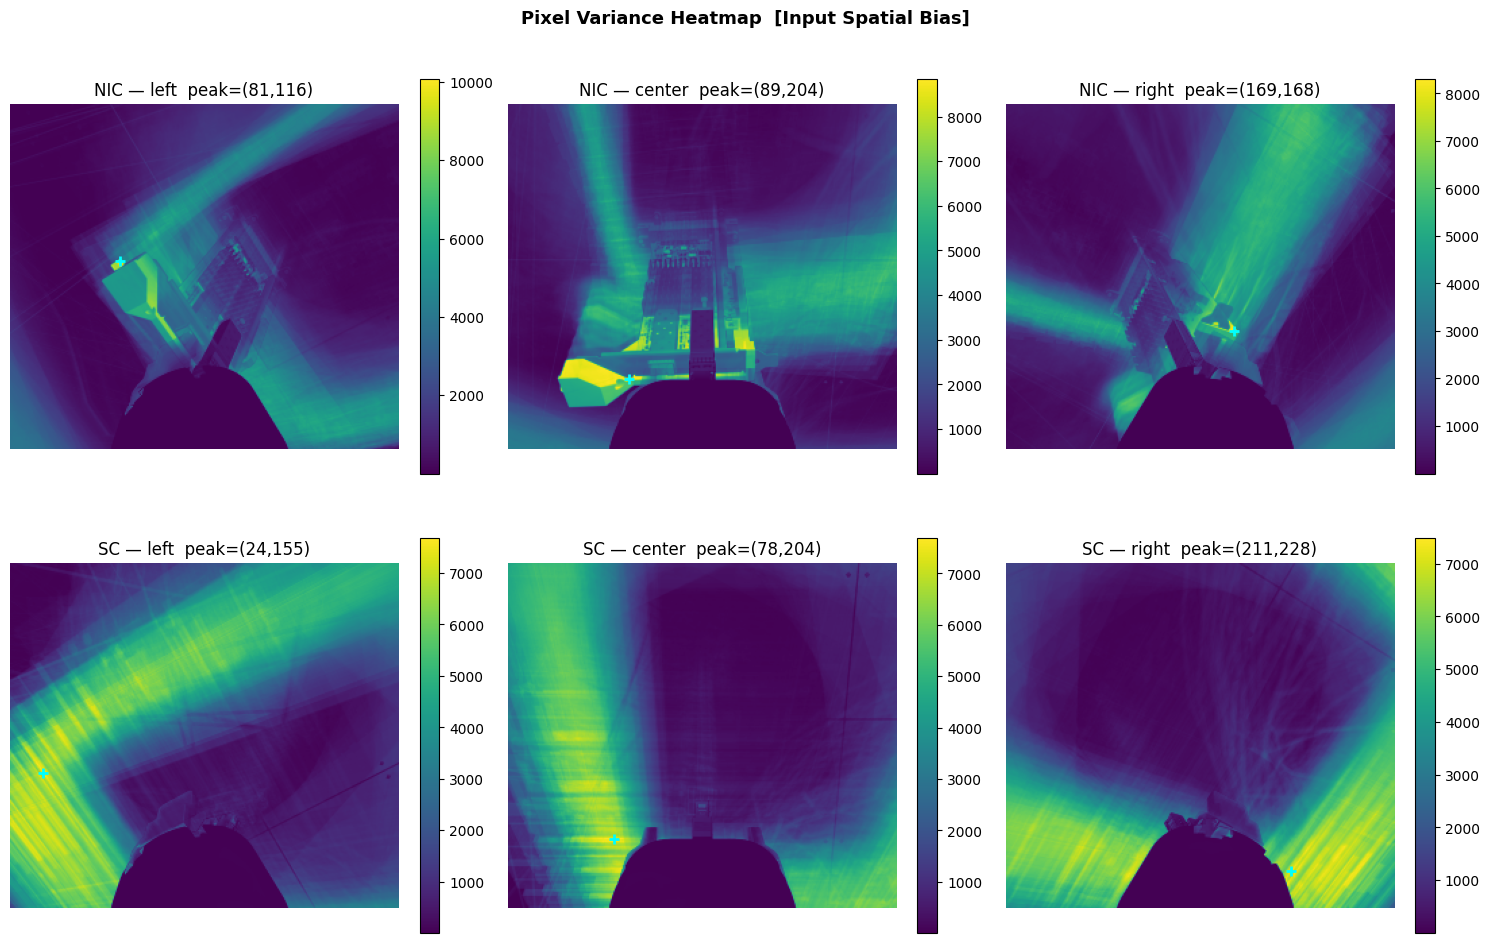


Spatial concentration (fraction of pixels holding 50% of variance energy):
  view     task   value   note
  center   nic    0.185   caution
  center   sc     0.180   caution
  left     nic    0.156   caution
  left     sc     0.220   caution
  right    nic    0.182   caution
  right    sc     0.161   caution


In [8]:
# ── 3-2: Spatial variance heatmap — where does motion concentrate? ────────────
# High variance pixel = robot/plug passes through that location frequently
# If concentrated → spatial input bias

var_maps = {} # (view, task) 조합별로, 해당 조합의 모든 프레임에 걸쳐 픽셀마다 분산을 계산한 2D 맵
for (view, task), sub in tqdm(img_df.groupby(['view','task_type']), desc='Variance maps'):
    frames = []
    for path in sub['path']:
        try: frames.append(load_gray(path))
        except: continue
    if len(frames) > 1:
        var_maps[(view, task)] = np.stack(frames).var(axis=0) # (H, W)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for row_i, task in enumerate(['nic','sc']):
    for col_i, view in enumerate(VIEWS): # [left, right, center]
        ax = axes[row_i][col_i]
        vm = var_maps.get((view, task))
        if vm is None: continue
        im = ax.imshow(vm)
        plt.colorbar(im, ax=ax, fraction=0.046)
        hy, hx = np.unravel_index(vm.argmax(), vm.shape)
        ax.scatter([hx],[hy], c='cyan', s=60, marker='+', linewidths=2)
        ax.set_title(f'{task.upper()} — {view}  peak=({hx},{hy})')
        ax.axis('off')

plt.suptitle('Pixel Variance Heatmap  [Input Spatial Bias]', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Spatial concentration: what fraction of pixels hold 50% of variance energy?
def spatial_conc(vm, thr=0.5):
    flat = np.sort(vm.flatten())[::-1]
    cs = np.cumsum(flat) # 누적합
    n = np.searchsorted(cs, cs[-1]*thr) + 1 # 누적합이 전체의 50%에 도달하는 인덱스
    return n / flat.size

print('\nSpatial concentration (fraction of pixels holding 50% of variance energy):')
print(f'  {"view":8s} {"task":5s}  value   note')
for (view, task), vm in sorted(var_maps.items()):
    c = spatial_conc(vm)
    flag = 'BIASED' if c < 0.15 else ('OK' if c > 0.30 else 'caution')
    print(f'  {view:8s} {task:5s}  {c:.3f}   {flag}')


## Section 4-1 — CV 특징 함수 정의

이후 4-2~4-5에서 사용되는 이미지 특징 추출 함수들을 정의합니다.

| 함수 | 측정 대상 | 의미 |
|------|----------|------|
| `fft_high_ratio` | 고주파 에너지 비율 | 높을수록 엣지/텍스처 풍부 |
| `hue_entropy` | 색상 다양성 (엔트로피) | 높을수록 다채로운 색상 분포 |
| `fg_bbox` | 전경 blob 중심 좌표 | 물체가 이미지 어느 위치에 있는가 |

> **참고**: 이 셀은 함수 정의만 합니다. 실행 결과는 4-2부터 나타납니다.


In [9]:

# ── 4-1: CV feature functions ────────────────────────────────────────────────
def fft_high_ratio(gray, frac=0.18):
    f = np.fft.fftshift(np.fft.fft2(gray.astype(np.float32)))
    mag = np.abs(f)
    h, w = gray.shape
    cy, cx = h//2, w//2
    ry, rx = int(h*frac/2), int(w*frac/2)
    mask = np.zeros_like(gray, dtype=bool)
    mask[cy-ry:cy+ry+1, cx-rx:cx+rx+1] = True
    return float(mag[~mask].sum() / (mag.sum()+1e-6))

def hue_entropy(hsv, bins=36):
    sat = hsv[:,:,1]
    hue = hsv[:,:,0]
    valid = sat > 25
    if valid.sum() < 64: return np.nan
    hist, _ = np.histogram(hue[valid], bins=bins, range=(0,180), density=True)
    hist = hist[hist>0]
    return float(-(hist * np.log(hist+1e-9)).sum())

def fg_bbox(rgb):
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    h, w = lab.shape[:2]
    border = np.concatenate([lab[:16].reshape(-1,3), lab[-16:].reshape(-1,3),
                              lab[:,:16].reshape(-1,3), lab[:,-16:].reshape(-1,3)])
    dist = np.linalg.norm(lab.astype(np.float32) - np.median(border,0).astype(np.float32), axis=2)
    mask = ((dist > np.percentile(dist,82))*255).astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  np.ones((5,5),np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9,9),np.uint8))
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    ic = np.array([w/2, h/2])
    best, bscore = None, None
    for i in range(1, n):
        a = stats[i, cv2.CC_STAT_AREA]
        if a < 80: continue
        cx = stats[i, cv2.CC_STAT_LEFT] + stats[i, cv2.CC_STAT_WIDTH]/2
        cy = stats[i, cv2.CC_STAT_TOP]  + stats[i, cv2.CC_STAT_HEIGHT]/2
        s = a - 3000*np.linalg.norm((np.array([cx,cy])-ic)/np.array([w,h]))
        if bscore is None or s > bscore: bscore, best = s, i
    if best is None: return np.nan, np.nan
    s = stats[best]
    return (s[cv2.CC_STAT_LEFT]+s[cv2.CC_STAT_WIDTH]/2)/w, \
           (s[cv2.CC_STAT_TOP] +s[cv2.CC_STAT_HEIGHT]/2)/h

print('CV functions ready')


CV functions ready


## Section 4-2 — CV 특징 추출

### 무엇을 보는가
세션별로 approach / insert 위상의 프레임을 샘플링하여  
laplacian_var, noise_std, fft_high, edge_density, brightness, saturation, hue_entropy, fg_cx/cy  
를 계산하고 `cv_df`에 저장합니다.

### 어떻게 판단하는가
- `CV records` 수가 `세션수 × N_PER_PHASE × 2(위상) × 3(뷰)` 에 근접하면 정상.
- 크게 적으면 이미지 읽기 오류 세션 존재 → try/except가 처리했지만 로그 확인 권장.


In [10]:

# ── 4-2: CV feature extraction (view x task_type x phase) ────────────────────
N_PER_PHASE = 12
cv_rows = []

for sess_dir in tqdm(ALL_SESSIONS, desc='CV features'):
    info = parse_session(sess_dir)
    with open(sess_dir / 'steps.jsonl') as f:
        all_lines = f.readlines()
    phase_groups = {'approach':[], 'insert':[]}
    for ln in all_lines:
        d = json.loads(ln)
        if d['phase'] in phase_groups:
            phase_groups[d['phase']].append(d)

    for ph, records in phase_groups.items():
        step = max(1, len(records)//N_PER_PHASE)
        for d in records[::step][:N_PER_PHASE]:
            obs = d.get('observation', {})
            for view in VIEWS:
                key = f'{view}_image'
                if key not in obs: continue
                try:
                    rgb  = load_rgb(Path(obs[key]['path']))
                    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
                    gf   = gray.astype(np.float32)
                    hsv  = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
                    val, sat = hsv[:,:,2], hsv[:,:,1]

                    lap  = float(cv2.Laplacian(gf, cv2.CV_32F).var())
                    ns   = float((gf - cv2.GaussianBlur(gf,(0,0),1.0)).std())
                    fft  = fft_high_ratio(gray)
                    edge = float((cv2.Canny(gray,40,120)>0).mean())
                    bri  = float(val.mean()/255)
                    sat_m= float(sat.mean()/255)
                    hent = hue_entropy(hsv)
                    fx, fy = fg_bbox(rgb)

                    cv_rows.append({
                        'session': info['session'], 'task_type': info['task_type'],
                        'phase': ph, 'view': view,
                        'laplacian_var': lap, 'noise_std': ns,
                        'fft_high': fft, 'edge_density': edge,
                        'brightness': bri, 'saturation': sat_m, 'hue_entropy': hent,
                        'fg_cx': fx, 'fg_cy': fy,
                    })
                except Exception: continue

cv_df = pd.DataFrame(cv_rows)
print(f'CV records: {len(cv_df):,}')

CV features:   0%|          | 0/56 [00:00<?, ?it/s]

CV records: 4,032


## Section 4-3 — 노이즈 / 텍스처 / 주파수 (Input Feature Bias)

### 무엇을 보는가
laplacian_var (선명도 ; 높을 수록 또렷한 이미지 ), noise_std (고주파 노이즈), fft_high_ratio (주파수 분포),  
edge_density (엣지 밀도)를 뷰 × task_type × phase 조합으로 boxplot 비교합니다.

### 어떻게 판단하는가
| 특징 | 확인 포인트 | 이상 신호 |
|------|-----------|----------|
| laplacian_var | approach vs insert 차이 | insert가 극도로 낮음 → 흐릿한 근접 촬영 (정상 범위) |
| noise_std | 뷰 간 차이 | 특정 뷰만 높음 → 카메라 센서 노이즈 차이 |
| fft_high_ratio | task 간 차이 | NIC ≠ SC 이면 텍스처 복잡도 다름 → 인코더 용량 설정에 반영 |
| edge_density | phase 간 차이 | approach > insert 이면 정상 (가까울수록 엣지 감소) |

특징값 분포가 phase별로 크게 다르면 → phase-conditional augmentation 또는 별도 헤드 고려.


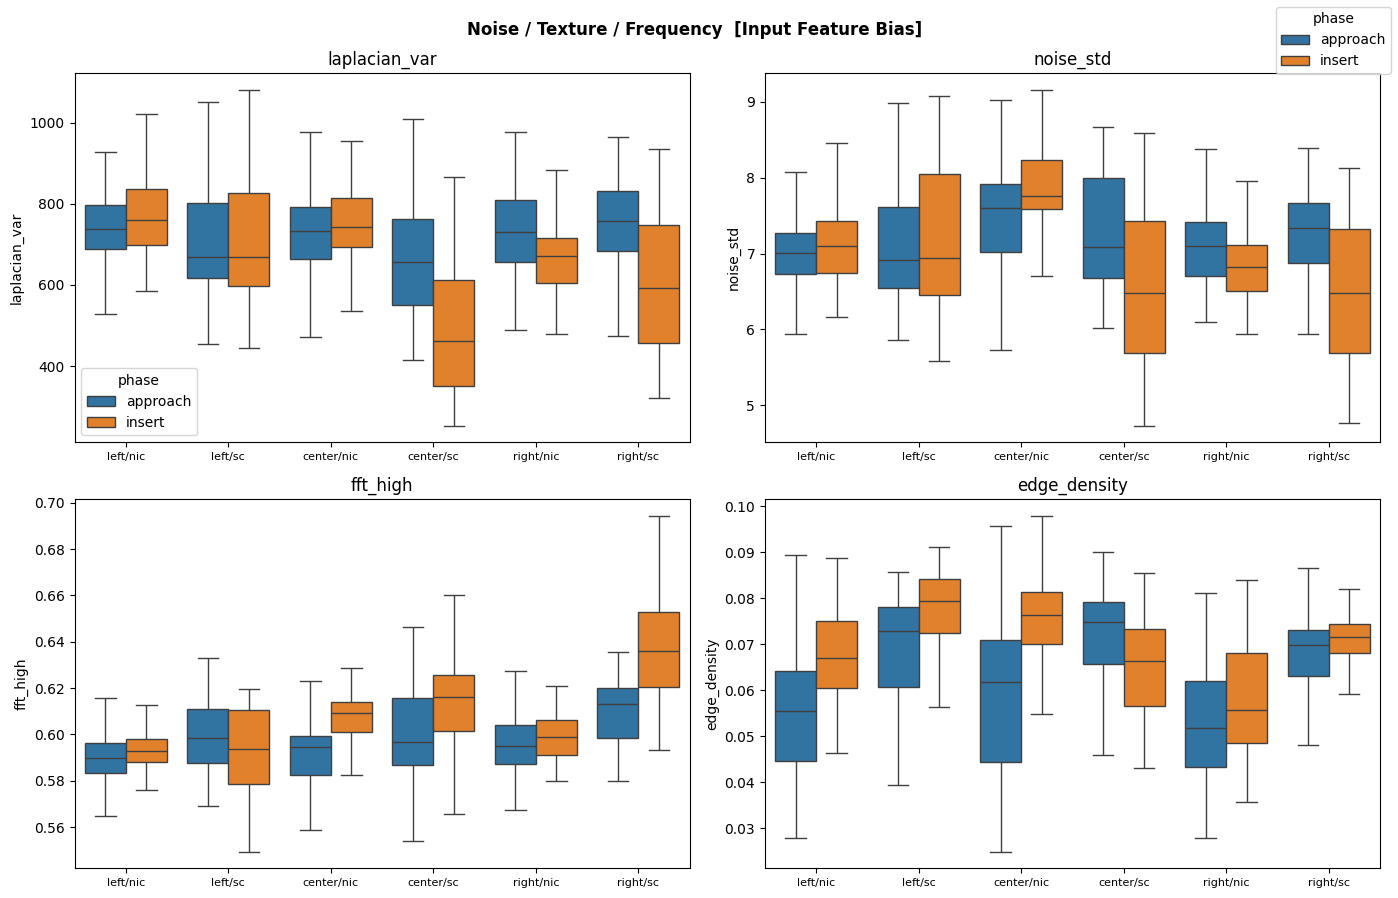

In [12]:

# ── 4-3: Noise / Texture / Frequency  (view x phase) ─────────────────────────
cv_df['view_task'] = cv_df['view'] + '/' + cv_df['task_type']
order = [f'{v}/{t}' for v in VIEWS for t in ['nic','sc']]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat,
                   ['laplacian_var','noise_std','fft_high','edge_density']):
    sns.boxplot(data=cv_df, x='view_task', y=col, hue='phase',
                order=order, ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=8)
    if ax != axes.flat[0]:
        legend = ax.get_legend()
        if legend: legend.remove()

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', title='phase')
plt.suptitle('Noise / Texture / Frequency  [Input Feature Bias]', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 4-4 — HSV 스칼라 특징 (Input Appearance Bias)

### 무엇을 보는가
brightness (명도), saturation (채도), hue_entropy (색상 다양성)를 뷰 × task_type으로 비교하고,  
추가로 approach vs insert 간 brightness 분포 차이를 히스토그램으로 시각화합니다.

### 어떻게 판단하는가
**뷰 간 비교**
- brightness: 세 뷰가 비슷하면 조명 균일 → 좋음. 특정 뷰만 극도로 어두우면 카메라 각도 문제.
- hue_entropy: 낮으면(< 1.5) 색상이 단조로움 → ColorJitter augmentation 필수.

**Phase-domain Shift (하단 히스토그램)**
| 패턴 | 의미 | 대응 |
|------|------|------|
| approach / insert 분포 완전히 겹침 | 위상 변화가 밝기에 영향 없음 → 좋음 | 별도 처리 불필요 |
| approach가 전반적으로 밝음 | 먼 거리 → 배경 비율 높음 | 정상 (거리 감소로 배경 가려짐) |
| insert가 더 밝음 | 근접 시 조명 반사 → 포화 위험 | Brightness 상한 clipping 고려 |


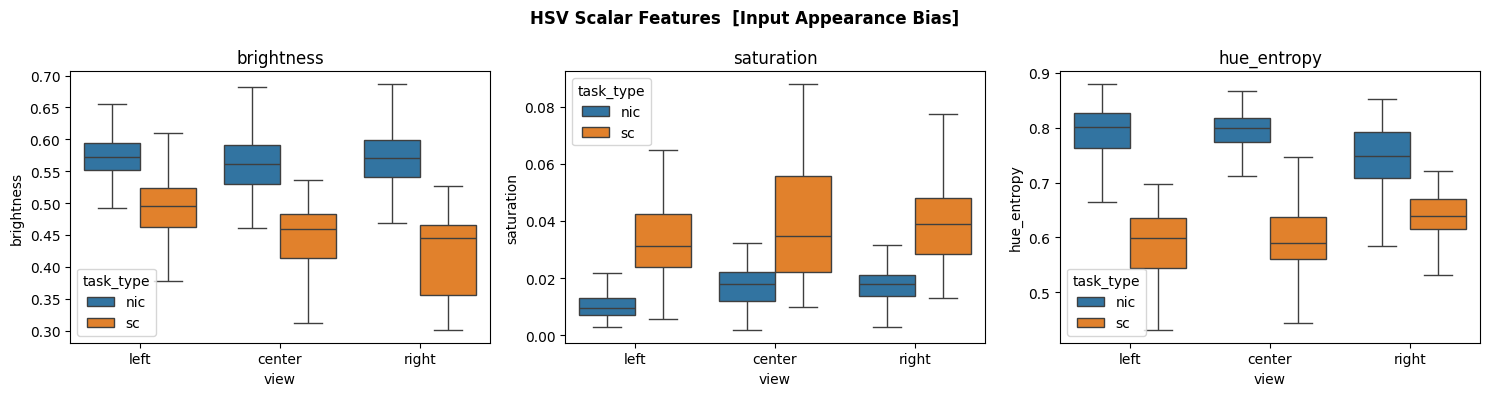

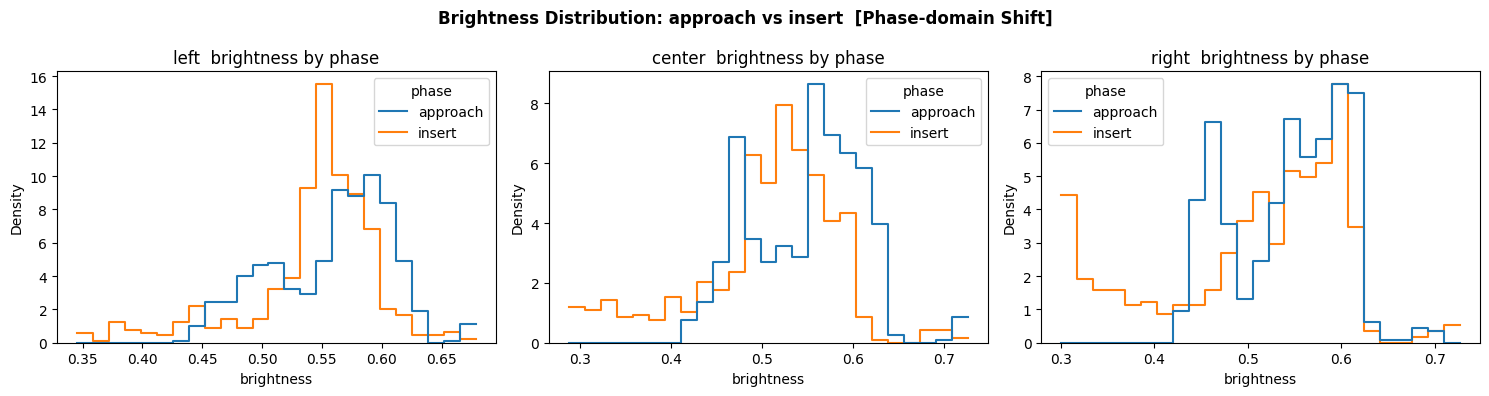

In [13]:

# ── 4-4: HSV scalar features  (view x task) ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['brightness','saturation','hue_entropy']):
    sns.boxplot(data=cv_df, x='view', y=col, hue='task_type', ax=ax, showfliers=False)
    ax.set_title(col)

plt.suptitle('HSV Scalar Features  [Input Appearance Bias]', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# brightness distribution by phase (key: are approach/insert frames visually different?)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, view in zip(axes, VIEWS):
    sns.histplot(data=cv_df[cv_df['view']==view], x='brightness', hue='phase',
                 bins=25, stat='density', common_norm=False,
                 element='step', fill=False, ax=ax)
    ax.set_title(f'{view}  brightness by phase')
plt.suptitle('Brightness Distribution: approach vs insert  [Phase-domain Shift]', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 5-1 — Cross-view 픽셀 차이 (View Diversity)

### 무엇을 보는가
동일 시점(same step)에서 left / center / right 뷰를 pair별로 픽셀 차이를 구하고  
그 평균을 히트맵으로 시각화합니다.

### 어떻게 판단하는가
| mean diff | 의미 | 인코더 설계 시사점 |
|-----------|------|-------------------|
| > 20 (0~255 scale) | 뷰 간 시각 정보 차이가 큼 | 뷰별 독립 인코더 또는 뷰 ID 임베딩 필요 |
| 10 ~ 20 | 중간 다양성 | 공유 인코더 + 뷰별 어댑터 고려 |
| < 10 | 뷰 간 차이 거의 없음 | 단일 공유 인코더로 충분 |

**히트맵 패턴**: 차이가 집중된 영역이 로봇 관절/그리퍼 위치와 일치하면 정상.  
배경에서 차이가 크면 카메라 화이트밸런스 또는 노출 설정이 다른 것이므로 전처리 시 normalize 필요.


Pixel diff:   0%|          | 0/10 [00:00<?, ?it/s]

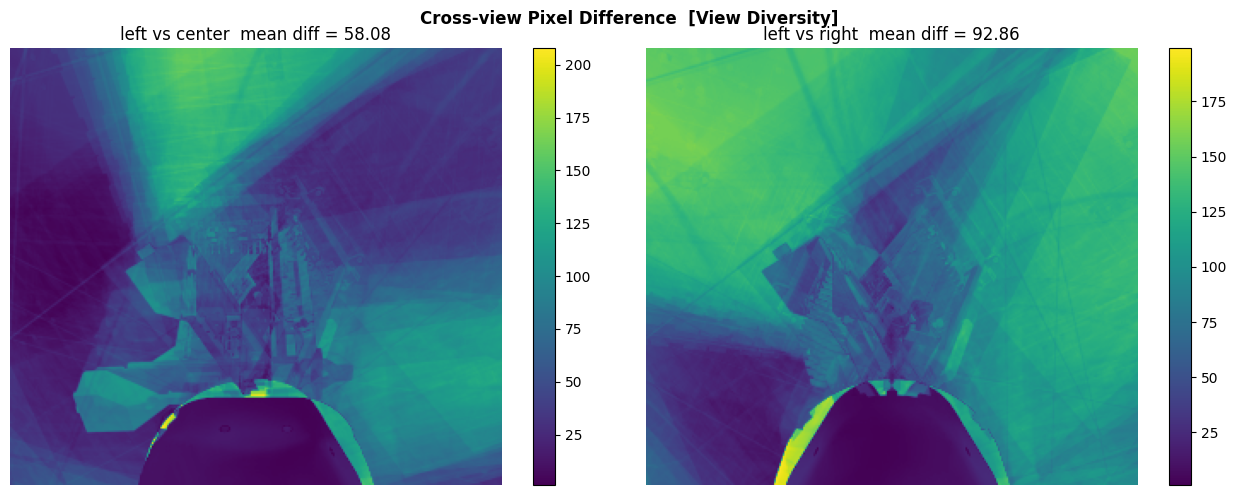

Frames used: 100


In [14]:

# ── 5-1: Cross-view pixel difference  (same frame, insert phase) ─────────────
diff_lc = np.zeros((RESIZE_H, RESIZE_W))
diff_lr = np.zeros((RESIZE_H, RESIZE_W))
n = 0
for sess_dir in tqdm(ALL_SESSIONS[:10], desc='Pixel diff'):
    with open(sess_dir / 'steps.jsonl') as f:
        lines = f.readlines()
    ins = [l for l in lines if json.loads(l)['phase']=='insert']
    for ln in ins[::max(1,len(ins)//10)][:10]:
        d = json.loads(ln)
        obs = d.get('observation', {})
        paths = {v: obs.get(f'{v}_image',{}).get('path') for v in VIEWS}
        if not all(paths.values()): continue
        try:
            lg = load_gray(Path(paths['left']))
            cg = load_gray(Path(paths['center']))
            rg = load_gray(Path(paths['right']))
            diff_lc += np.abs(lg - cg)
            diff_lr += np.abs(lg - rg)
            n += 1
        except: continue

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, dm, title in [(axes[0], diff_lc/n, 'left vs center'),
                      (axes[1], diff_lr/n, 'left vs right')]:
    im = ax.imshow(dm)
    plt.colorbar(im, ax=ax)
    ax.set_title(f'{title}  mean diff = {dm.mean():.2f}')
    ax.axis('off')

plt.suptitle('Cross-view Pixel Difference  [View Diversity]', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Frames used: {n}')


## Section 5-2 — Cross-view 특징 상관관계 (Shared Encoder Validity)

### 무엇을 보는가
같은 스텝에서 left / center / right 뷰의 brightness, laplacian, fft, edge 값을  
pairwise Pearson r로 비교합니다. 뷰 간 상관이 높으면 같은 장면을 보고 있다는 의미입니다.

### 어떻게 판단하는가
| Pearson r | 의미 | 인코더 설계 결론 |
|-----------|------|----------------|
| > 0.80 (모든 특징) | 뷰들이 동일한 시각 정보 공유 | **단일 공유 인코더 사용 가능** ✅ |
| 0.50 ~ 0.80 | 부분적 공유 | 공유 인코더 + 뷰별 projection head |
| < 0.50 (일부 특징) | 특정 특징에서 뷰 간 정보 독립 | 뷰별 독립 인코더 권장 |

**특히 주목할 특징**: brightness r이 높으면 조명이 균일, laplacian r이 낮으면 뷰마다 초점 거리가 달라  
선명도 정보가 다를 수 있음 → 이 경우 blur augmentation의 강도를 뷰별로 달리 설정하세요.


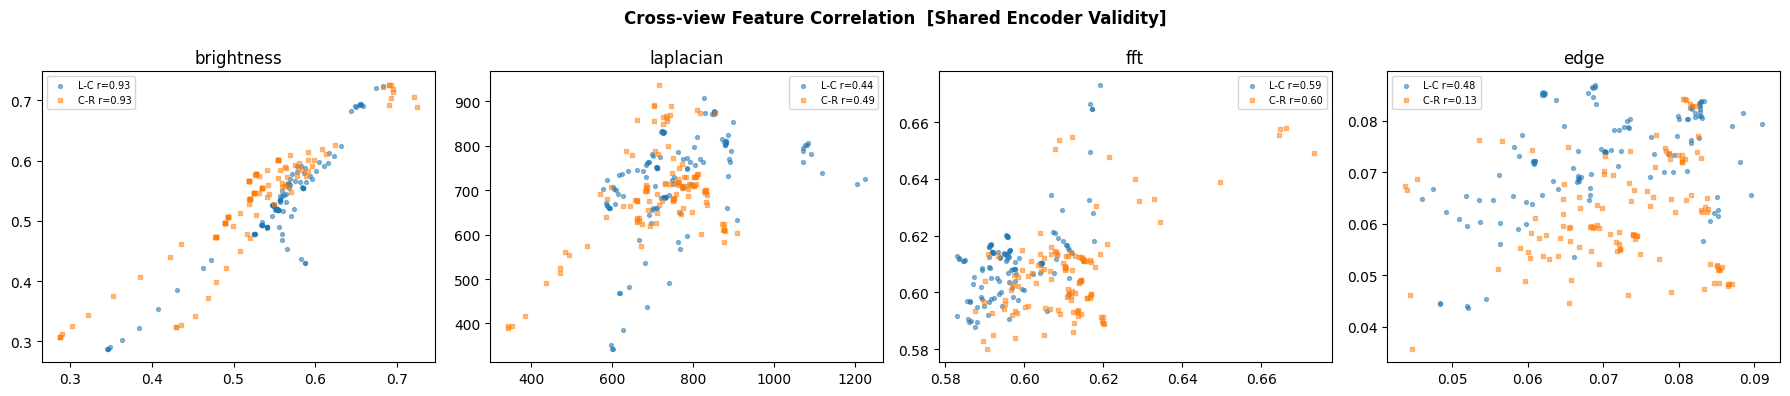


Pearson r (r>0.8 = views carry similar info → shared encoder OK):


,L-C,L-R,C-R
brightness,0.934,0.791,0.934
laplacian,0.443,0.337,0.491
fft,0.589,0.623,0.601
edge,0.481,0.527,0.134


In [15]:

# ── 5-2: Cross-view feature correlation ──────────────────────────────────────
# High correlation → views carry similar info → shared encoder assumption holds

# Pivot to wide: one row per (session, step)
cv_wide_rows = []
for sess_dir in ALL_SESSIONS[:12]:
    info = parse_session(sess_dir)
    with open(sess_dir / 'steps.jsonl') as f:
        lines = f.readlines()
    ins = [json.loads(l) for l in lines if json.loads(l)['phase']=='insert']
    for d in ins[::max(1,len(ins)//10)][:10]:
        obs = d.get('observation', {})
        row = {'session': info['session'], 'step': d['step']}
        all_ok = True
        for view in VIEWS:
            k = f'{view}_image'
            if k not in obs: all_ok = False; break
            try:
                rgb  = load_rgb(Path(obs[k]['path']))
                gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
                hsv  = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
                row[f'{view}_brightness'] = float(hsv[:,:,2].mean()/255)
                row[f'{view}_laplacian']  = float(cv2.Laplacian(gray,cv2.CV_32F).var())
                row[f'{view}_fft']        = fft_high_ratio(gray.astype(np.uint8))
                row[f'{view}_edge']       = float((cv2.Canny(gray.astype(np.uint8),40,120)>0).mean())
            except: all_ok = False; break
        if all_ok: cv_wide_rows.append(row)

wide_df = pd.DataFrame(cv_wide_rows)

feat_names = ['brightness','laplacian','fft','edge']
fig, axes = plt.subplots(1, len(feat_names), figsize=(18, 4))
corr_out = {}
for ax, feat in zip(axes, feat_names):
    lc = f'left_{feat}'; cc = f'center_{feat}'; rc = f'right_{feat}'
    if not all(c in wide_df for c in [lc,cc,rc]): continue
    r_lc = wide_df[lc].corr(wide_df[cc])
    r_lr = wide_df[lc].corr(wide_df[rc])
    r_cr = wide_df[cc].corr(wide_df[rc])
    corr_out[feat] = {'L-C': r_lc, 'L-R': r_lr, 'C-R': r_cr}
    ax.scatter(wide_df[lc], wide_df[cc], alpha=0.5, s=8, label=f'L-C r={r_lc:.2f}')
    ax.scatter(wide_df[cc], wide_df[rc], alpha=0.5, s=8, marker='s', label=f'C-R r={r_cr:.2f}')
    ax.set_title(feat); ax.legend(fontsize=7)

plt.suptitle('Cross-view Feature Correlation  [Shared Encoder Validity]', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nPearson r (r>0.8 = views carry similar info → shared encoder OK):')
display(pd.DataFrame(corr_out).T.round(3))


## Section 6 — Bias Summary (설계 결론)

### 무엇을 보는가
Section 1~5에서 발견한 편향들을 하나의 표로 정리하고,  
백본 인코더 학습 전 반드시 적용해야 할 조치를 우선순위 순으로 출력합니다.

### 어떻게 판단하는가
**우선순위 결정 기준**

| 편향 종류 | 영향 범위 | 조치 긴급도 |
|-----------|----------|-------------|
| Phase 불균형 (input) | 모든 학습 배치 | 🔴 필수 — 오버샘플링 또는 가중치 샘플링 |
| Task 불균형 (input) | 모든 학습 배치 | 🔴 필수 — 배치 내 1:1 샘플링 |
| Tip error bias (output) | 정책 일반화 | 🟡 중요 — 삽입 시작점 다양화 |
| 공간 편향 BIASED (input) | 인코더 ROI | 🟡 중요 — RandomCrop / Affine |
| 공간 편향 caution (input) | 인코더 ROI | 🟢 권장 — 약한 augmentation |

> **최종 체크리스트**: 이 셀의 RECOMMENDATIONS 항목이 모두 학습 코드에 반영되었는지  
> 학습 시작 전 확인하세요. 이 분석에서 발견하지 못한 편향은 Section 7~9에서 보완됩니다.


In [18]:

# ── 6: Bias Summary ──────────────────────────────────────────────────────────
phase_cnt = steps_df['phase'].value_counts()
task_cnt  = steps_df['task_type'].value_counts()
ins = steps_df[steps_df['phase']=='insert']

print('='*65)
print('  Bias Summary')
print('='*65)

print('\n[1] PHASE IMBALANCE  (input frame distribution)')
for ph in ['approach','insert','stabilize']:
    c = phase_cnt.get(ph, 0)
    print(f'    {ph:12s}: {c:6d}  ({c/phase_cnt.sum()*100:.1f}%)')
print('    -> oversample approach or subsample insert uniformly')

print('\n[2] TASK TYPE IMBALANCE')
for t, c in task_cnt.items():
    print(f'    {t:6s}: {c:6d}  ({c/task_cnt.sum()*100:.1f}%)')
print('    -> balanced batch sampling 1:1')

print('\n[3] TIP ERROR  (output distribution)')
for task in ['nic','sc']:
    sub = ins[ins['task_type']==task]
    xe, ye = sub['tip_x_error'].mean()*1000, sub['tip_y_error'].mean()*1000
    xs, ys = sub['tip_x_error'].std()*1000,  sub['tip_y_error'].std()*1000
    sym = 'BIASED' if abs(xe)>xs*0.3 or abs(ye)>ys*0.3 else 'symmetric'
    print(f'    {task.upper()}: x={xe:+.2f}mm (std={xs:.2f})  y={ye:+.2f}mm (std={ys:.2f})  [{sym}]')
print('    -> add Gaussian offset at insert start to diversify error range')

print('\n[4] SPATIAL INPUT BIAS  (see variance heatmap)')
for (view, task), vm in sorted(var_maps.items()):
    c = spatial_conc(vm)
    flag = 'BIASED' if c < 0.15 else ('OK' if c > 0.30 else 'caution')
    print(f'    {task:4s} {view:7s}: {c:.3f}  [{flag}]')
print('    -> RandomCrop / Affine augmentation if BIASED')

print('\n[5] RECOMMENDATIONS')
recs = [
    '1. Oversample approach ~4x relative to insert',
    '2. Batch sample nic:sc = 1:1',
    '3. Add Gaussian XY offset (sigma~5mm) at insert start for diverse tip_error',
    '4. For spatially biased views: RandomCrop + AffineTransform augmentation',
    '5. Temporal shuffle within session to prevent z_offset overfitting',
]
for r in recs:
    print(f'   {r}')


  Bias Summary

[1] PHASE IMBALANCE  (input frame distribution)
    approach    :   4200  (18.8%)
    insert      :  18060  (81.0%)
    stabilize   :     42  (0.2%)
    -> oversample approach or subsample insert uniformly

[2] TASK TYPE IMBALANCE
    nic   :  15930  (71.4%)
    sc    :   6372  (28.6%)
    -> balanced batch sampling 1:1

[3] TIP ERROR  (output distribution)
    NIC: x=+0.18mm (std=1.85)  y=+0.02mm (std=1.66)  [symmetric]
    SC: x=+7.73mm (std=5.39)  y=-1.51mm (std=3.36)  [BIASED]
    -> add Gaussian offset at insert start to diversify error range

[4] SPATIAL INPUT BIAS  (see variance heatmap)
    nic  center : 0.189  [caution]
    sc   center : 0.184  [caution]
    nic  left   : 0.156  [caution]
    sc   left   : 0.228  [caution]
    nic  right  : 0.187  [caution]
    sc   right  : 0.162  [caution]
    -> RandomCrop / Affine augmentation if BIASED

[5] RECOMMENDATIONS
   1. Oversample approach ~4x relative to insert
   2. Batch sample nic:sc = 1:1
   3. Add Gaussian X

## Section 7 — Temporal Redundancy (프레임 간 시간적 중복성)

### 무엇을 보는가
연속된 두 프레임이 얼마나 '다른가'를 시간 축으로 측정합니다.  
구체적으로는 mean absolute pixel difference (MAD)와 SSIM(Structural Similarity)을 
step 단위로 계산해 분포를 시각화합니다.

### 어떻게 판단하는가
| MAD 평균 | 의미 | 대응 |
|----------|------|------|
| < 1.5 (0~255 scale) | 연속 프레임이 사실상 동일 — 10Hz 샘플링에도 중복 심각 | 학습 시 temporal stride 3~5 이상 권장 |
| 1.5 ~ 5 | 적당한 변화량 — 그대로 써도 무방 | stride 2 정도 |
| > 5 | 프레임 간 변화가 크다 — 모션이 빠르거나 policy 전환 구간 | stride 1, 모든 프레임 활용 |

**핵심 질문 두 가지:**  
1. **approach vs insert 위상별 MAD 차이가 있는가?**  
   approach는 로봇이 빠르게 이동 → MAD가 높아야 정상.  
   insert는 미세 조정 → MAD가 낮아도 정상.  
   만약 두 위상이 비슷하다면 위상 구분이 시각적으로 어렵다는 신호.

2. **미니배치 내 유사 프레임 비율이 높은가?**  
   SSIM > 0.95인 연속 프레임 비율이 30% 이상이면 배치 샘플링 시  
   temporal stride 또는 random interval sampling 전략이 필요합니다.

Temporal redundancy:   0%|          | 0/10 [00:00<?, ?it/s]

Consecutive frame pairs analyzed: 5,300


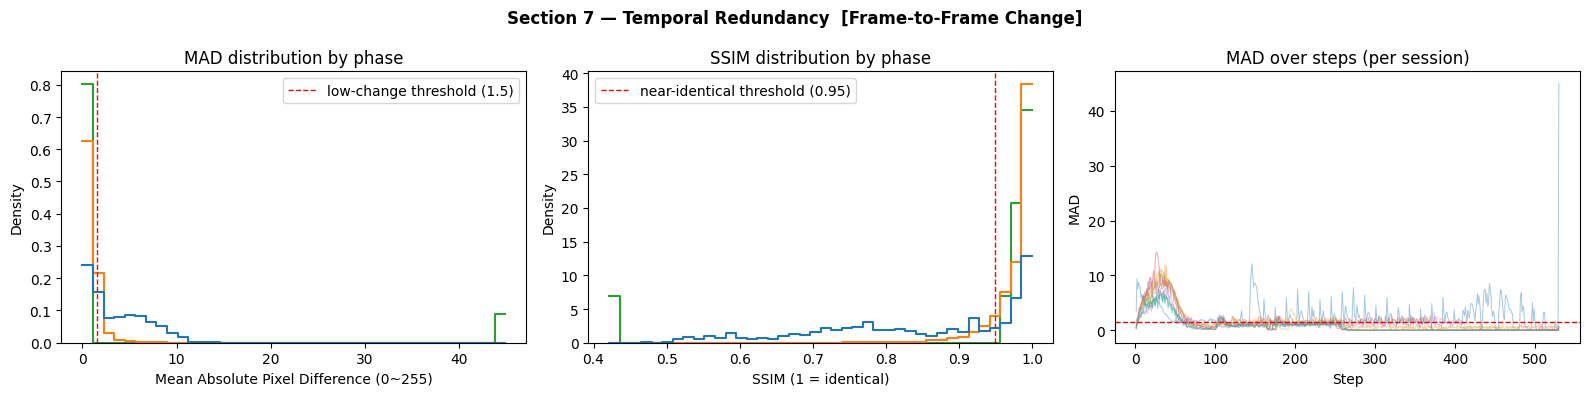


Fraction of pairs with SSIM > 0.95: 76.60%
  → ⚠️  REDUNDANT — temporal stride >= 3 recommended

MAD stats by phase:


,count,mean,std,min,25%,50%,75%,max
phase,,,,,,,,
approach,990.0,3.726,3.034,0.106,1.042,2.875,5.981,14.245
insert,4300.0,0.797,1.030,0.003,0.042,0.579,1.229,12.110
stabilize,10.0,4.856,14.078,0.053,0.146,0.448,0.720,44.915


In [17]:
# ── Section 7: Temporal Redundancy ───────────────────────────────────────────
# Measures how similar consecutive frames are.
# MAD (Mean Absolute pixel Difference): lower = frames are nearly identical
# SSIM: closer to 1 = structurally identical images
#
# Decision criteria:
#   SSIM > 0.95 ratio > 30% → severe redundancy → temporal stride ≥ 3 recommended
#   MAD < 1.5              → consecutive frames are virtually the same

from skimage.metrics import structural_similarity as ssim_fn

# ── 7-1: Compute MAD / SSIM for each consecutive frame pair ──────────────────
N_SESSIONS_TEMP   = min(10, len(ALL_SESSIONS))
RESIZE_TEMP_H     = 128
RESIZE_TEMP_W     = 144   # downscaled for speed

SSIM_THRESHOLD    = 0.95  # above this → "nearly identical frames"
MAD_LOW_THRESHOLD = 1.5   # below this → "virtually no change"

temp_rows = []

for sess_dir in tqdm(ALL_SESSIONS[:N_SESSIONS_TEMP], desc='Temporal redundancy'):
    info  = parse_session(sess_dir)
    steps = [json.loads(ln) for ln in open(sess_dir / 'steps.jsonl')]

    prev_gray = None
    for d in steps:
        # Use center view as the representative view
        img_meta = d.get('observation', {}).get('center_image')
        if img_meta is None:
            prev_gray = None
            continue

        try:
            img = cv2.imread(str(Path(img_meta['path'])), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (RESIZE_TEMP_W, RESIZE_TEMP_H)).astype(np.float32)
        except Exception:
            prev_gray = None
            continue

        if prev_gray is not None:
            mad  = float(np.abs(img - prev_gray).mean())
            ssim = float(ssim_fn(img, prev_gray, data_range=255))
            temp_rows.append({
                'session':   info['session'],
                'task_type': info['task_type'],
                'phase':     d['phase'],
                'step':      d['step'],
                'mad':       mad,
                'ssim':      ssim,
            })

        prev_gray = img

temp_df = pd.DataFrame(temp_rows)
print(f'Consecutive frame pairs analyzed: {len(temp_df):,}')

# ── 7-2: Visualise ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# MAD distribution by phase
# → approach: high MAD expected (robot moving fast)
# → insert:   low MAD expected (fine adjustment)
sns.histplot(
    data=temp_df, x='mad', hue='phase', bins=40,
    stat='density', common_norm=False, element='step', fill=False, ax=axes[0]
)
axes[0].axvline(MAD_LOW_THRESHOLD, color='red', ls='--', lw=1,
                label=f'low-change threshold ({MAD_LOW_THRESHOLD})')
axes[0].set_title('MAD distribution by phase')
axes[0].set_xlabel('Mean Absolute Pixel Difference (0~255)')
axes[0].legend()

# SSIM distribution by phase
# → high ratio above 0.95 → too many redundant frames in batches
sns.histplot(
    data=temp_df, x='ssim', hue='phase', bins=40,
    stat='density', common_norm=False, element='step', fill=False, ax=axes[1]
)
axes[1].axvline(SSIM_THRESHOLD, color='red', ls='--', lw=1,
                label=f'near-identical threshold ({SSIM_THRESHOLD})')
axes[1].set_title('SSIM distribution by phase')
axes[1].set_xlabel('SSIM (1 = identical)')
axes[1].legend()

# MAD time-series per session
# → sudden drops = robot is stationary
for _, sg in temp_df.groupby('session'):
    axes[2].plot(sg['step'], sg['mad'], alpha=0.4, lw=0.7)
axes[2].axhline(MAD_LOW_THRESHOLD, color='red', ls='--', lw=1)
axes[2].set_title('MAD over steps (per session)')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('MAD')

plt.suptitle('Section 7 — Temporal Redundancy  [Frame-to-Frame Change]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 7-3: Summary ─────────────────────────────────────────────────────────────
high_ssim_ratio = (temp_df['ssim'] > SSIM_THRESHOLD).mean()

print(f'\nFraction of pairs with SSIM > {SSIM_THRESHOLD}: {high_ssim_ratio:.2%}')
print(f'  → {"⚠️  REDUNDANT — temporal stride >= 3 recommended" if high_ssim_ratio > 0.30 else "✅  OK — stride 1~2 sufficient"}')

print('\nMAD stats by phase:')
display(temp_df.groupby('phase')['mad'].describe().round(3))


## Section 8 — PCA / t-SNE Separability (시각적 분리 가능성)

### 무엇을 보는가
이미지 픽셀을 PCA로 차원 축소한 뒤 t-SNE로 2D 시각화합니다.  
각 점에 **task_type(NIC/SC)** 과 **phase(approach/insert)** 라벨을 색으로 표시합니다.

### 어떻게 판단하는가
**t-SNE 결과가 말해주는 것:**

| 패턴 | 의미 | 대응 |
|------|------|------|
| NIC / SC 클러스터가 명확히 분리 | 태스크 구분 정보가 이미지에 충분히 존재 | 인코더가 task-type feature를 학습할 수 있음 |
| NIC / SC가 완전히 섞임 | 두 태스크가 시각적으로 구별 불가 | 시각 정보 외 추가 모달리티 필요 |
| phase 라벨이 분리 | approach↔insert가 시각적으로 다름 | phase-conditional 인코더 고려 |
| phase 라벨이 섞임 | approach와 insert가 시각적으로 비슷 | phase를 visual signal로 쓰기 어려움 |

**PCA explained variance:**  
- 상위 10 PC가 분산의 70% 이상 설명 → 이미지 정보가 저차원에 집중 (좋음)  
- 50 PC를 써도 50% 미만 → 이미지가 복잡하거나 노이즈가 많음 → 더 큰 인코더 필요

> **주의:** t-SNE는 시각화 도구일 뿐, 클러스터 크기/거리는 정량적 의미가 없습니다.  
> 클러스터의 **유무**와 **라벨 순도**만 판단하세요.


Loading images for PCA:   0%|          | 0/42 [00:00<?, ?it/s]

Image matrix: (336, 4608)  (336 frames × 4608 pixels)


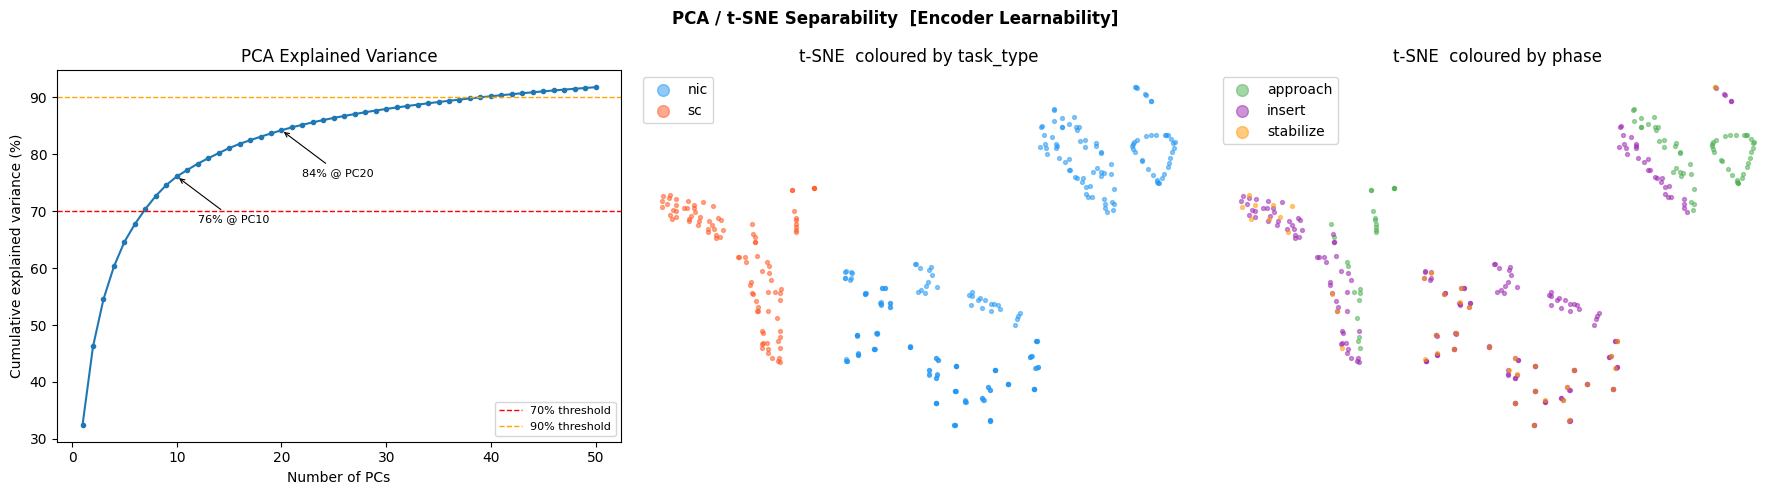

[NIC vs SC   ] linear acc=1.000  baseline=0.714  delta=+0.286  [SEPARABLE]
[phase       ] linear acc=0.813  baseline=0.625  delta=+0.188  [SEPARABLE]


In [ ]:
# ── 8-1: PCA / t-SNE separability ───────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

RESIZE_PCA_H, RESIZE_PCA_W = 64, 72   # small for PCA
N_PER_SESS_PCA = 8
N_PCA_COMPONENTS = 50

pca_rows, pca_imgs = [], []

for sess_dir in tqdm(ALL_SESSIONS, desc='Loading images for PCA'):
    info = parse_session(sess_dir)
    with open(sess_dir / 'steps.jsonl') as f:
        lines = f.readlines()
    idxs = np.linspace(0, len(lines)-1, N_PER_SESS_PCA, dtype=int)
    for i in idxs:
        d = json.loads(lines[i])
        obs = d.get('observation', {})
        key = 'center_image'
        if key not in obs:
            continue
        try:
            img = cv2.imread(str(Path(obs[key]['path'])), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (RESIZE_PCA_W, RESIZE_PCA_H)).astype(np.float32) / 255.0
            pca_imgs.append(img.flatten())
            pca_rows.append({
                'session':   info['session'],
                'task_type': info['task_type'],
                'phase':     d['phase'],
            })
        except Exception:
            continue

X = np.array(pca_imgs)
meta_df = pd.DataFrame(pca_rows)
print(f'Image matrix: {X.shape}  ({X.shape[0]} frames × {X.shape[1]} pixels)')

# PCA
n_components = min(N_PCA_COMPONENTS, X.shape[0] - 1)
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X)

# t-SNE on PCA embedding
tsne = TSNE(n_components=2, perplexity=min(30, len(X_pca)//4),
            random_state=42, max_iter=800, verbose=0)
X_2d = tsne.fit_transform(X_pca)

# ── 8-2: Plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) PCA explained variance
ev = np.cumsum(pca.explained_variance_ratio_) * 100
axes[0].plot(range(1, len(ev)+1), ev, marker='o', ms=3)
axes[0].axhline(70, color='red', ls='--', lw=1, label='70% threshold')
axes[0].axhline(90, color='orange', ls='--', lw=1, label='90% threshold')
for n, thr in [(10, 70), (20, 80)]:
    if n <= len(ev):
        axes[0].annotate(f'{ev[n-1]:.0f}% @ PC{n}',
                         xy=(n, ev[n-1]), xytext=(n+2, ev[n-1]-8), fontsize=8,
                         arrowprops=dict(arrowstyle='->', lw=0.8))
axes[0].set_xlabel('Number of PCs')
axes[0].set_ylabel('Cumulative explained variance (%)')
axes[0].set_title('PCA Explained Variance')
axes[0].legend(fontsize=8)

# (b) t-SNE coloured by task_type
palette = {'nic': '#2196F3', 'sc': '#FF5722'}
for task, color in palette.items():
    mask = meta_df['task_type'] == task
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, alpha=0.5, s=8, label=task)
axes[1].set_title('t-SNE  coloured by task_type')
axes[1].legend(markerscale=3)
axes[1].axis('off')

# (c) t-SNE coloured by phase
phase_palette = {'approach': '#4CAF50', 'insert': '#9C27B0', 'stabilize': '#FF9800'}
for phase, color in phase_palette.items():
    mask = meta_df['phase'] == phase
    if mask.sum() == 0: continue
    axes[2].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, alpha=0.5, s=8, label=phase)
axes[2].set_title('t-SNE  coloured by phase')
axes[2].legend(markerscale=3)
axes[2].axis('off')

plt.suptitle('PCA / t-SNE Separability  [Encoder Learnability]', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 8-3: Linear separability score (logistic regression on PCA features) ─────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

for label_col, label_name in [('task_type', 'NIC vs SC'), ('phase', 'phase')]:
    y = meta_df[label_col].values
    valid = ~pd.Series(y).isna()
    score = cross_val_score(
        LogisticRegression(max_iter=300, random_state=42),
        X_pca[valid], y[valid], cv=5, scoring='accuracy'
    ).mean()
    baseline = pd.Series(y[valid]).value_counts(normalize=True).max()
    delta = score - baseline
    flag = 'SEPARABLE' if delta > 0.10 else ('marginal' if delta > 0.03 else 'NOT separable')
    print(f'[{label_name:12s}] linear acc={score:.3f}  baseline={baseline:.3f}  '
          f'delta={delta:+.3f}  [{flag}]')


## Section 9 — Inter-session Diversity (세션 간 시각적 다양성)

### 무엇을 보는가
**같은 rail·task 조건**에서 수집된 서로 다른 세션들의 평균 이미지를 비교합니다.  
세션 간 brightness/hue 히스토그램 거리와 mean-image SSIM을 측정합니다.

### 어떻게 판단하는가
**인코더 overfitting 위험 지표:**

| 지표 | 임계값 | 의미 |
|------|--------|------|
| 세션 간 mean-image SSIM | > 0.90 | 모든 세션이 거의 같은 장면 → 인코더가 배경을 암기할 위험 |
| 세션 간 brightness std | < 0.02 | 조명 변화 없음 → 조명 다양성 augmentation 필수 |
| 세션 간 hue histogram L1 | < 0.05 | 색상 분포가 고정 → ColorJitter augmentation 필수 |

**핵심 해석 방법:**  
- Mean image가 세션마다 거의 동일하게 보이면 → 배경이 고정, 인코더가 배경 특징에 의존하게 됨  
- 세션 간 SSIM이 낮으면(< 0.7) → 수집 조건(조명, 물체 위치)에 이미 충분한 다양성  
- Rail별 다양성을 따로 보는 이유: 같은 rail은 카메라 앵글이 유사 → 더 취약

**결론으로 연결:**  
세션 간 다양성이 낮을수록 augmentation 강도를 높여야 하며,  
특히 ColorJitter, RandomBrightness, RandomAffine 등 외관 변화 aug가 효과적입니다.


Computing session mean images:   0%|          | 0/42 [00:00<?, ?it/s]

Sessions with mean image: 42


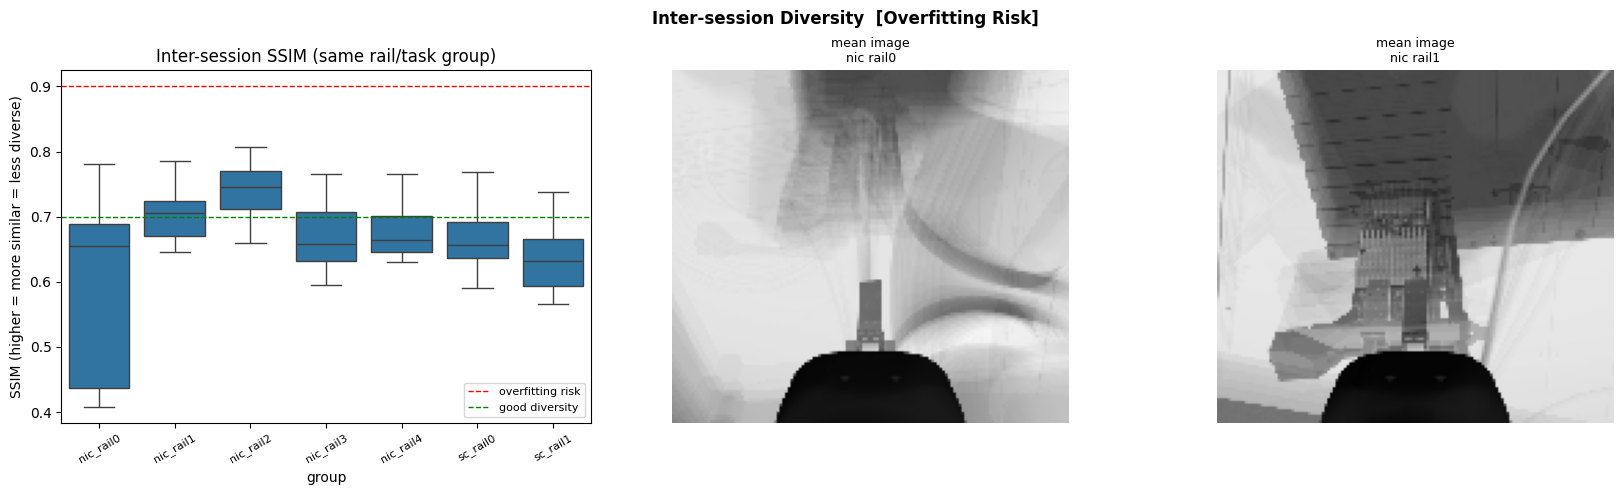


=== Inter-session Diversity Summary ===
  Mean inter-session SSIM (same group): 0.673  [OK]
  Brightness std across sessions      : 0.0720  [OK]

Recommended augmentation based on diversity:


In [22]:
# ── 9-1: Inter-session diversity ─────────────────────────────────────────────
# For each (task_type, rail) group: compute mean image per session → compare

from skimage.metrics import structural_similarity as ssim_fn

RESIZE_DIV_H, RESIZE_DIV_W = 128, 144
N_FRAMES_MEAN = 20  # frames per session for mean image

sess_means = {}   # (session_name) → mean_gray image
sess_meta  = {}   # (session_name) → {task_type, rail}

for sess_dir in tqdm(ALL_SESSIONS, desc='Computing session mean images'):
    info = parse_session(sess_dir)
    with open(sess_dir / 'steps.jsonl') as f:
        lines = f.readlines()
    idxs = np.linspace(0, len(lines)-1, N_FRAMES_MEAN, dtype=int)
    frames = []
    for i in idxs:
        d = json.loads(lines[i])
        obs = d.get('observation', {})
        key = 'center_image'
        if key not in obs: continue
        try:
            img = cv2.imread(str(Path(obs[key]['path'])), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (RESIZE_DIV_W, RESIZE_DIV_H)).astype(np.float32)
            frames.append(img)
        except Exception:
            continue
    if len(frames) >= 5:
        sess_means[info['session']] = np.mean(frames, axis=0)
        sess_meta[info['session']]  = {'task_type': info['task_type'], 'rail': info['rail']}

print(f'Sessions with mean image: {len(sess_means)}')

# ── 9-2: Pairwise SSIM within same (task_type, rail) group ───────────────────
from itertools import combinations

div_rows = []
groups = {}
for sname, meta in sess_meta.items():
    key = (meta['task_type'], meta['rail'])
    groups.setdefault(key, []).append(sname)

for group_key, sessions in groups.items():
    if len(sessions) < 2: continue
    for s1, s2 in combinations(sessions, 2):
        sim = ssim_fn(sess_means[s1], sess_means[s2], data_range=255)
        div_rows.append({
            'task_type': group_key[0], 'rail': group_key[1],
            'group': f"{group_key[0]}_{group_key[1]}",
            's1': s1, 's2': s2, 'ssim': sim
        })

div_df = pd.DataFrame(div_rows)

# ── 9-3: Visualise ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) SSIM distribution
if len(div_df):
    sns.boxplot(data=div_df, x='group', y='ssim', ax=axes[0], showfliers=False)
    axes[0].axhline(0.90, color='red', ls='--', lw=1, label='overfitting risk')
    axes[0].axhline(0.70, color='green', ls='--', lw=1, label='good diversity')
    axes[0].set_title('Inter-session SSIM (same rail/task group)')
    axes[0].set_ylabel('SSIM (higher = more similar = less diverse)')
    axes[0].tick_params(axis='x', labelrotation=30, labelsize=8)
    axes[0].legend(fontsize=8)

# (b) Mean images side-by-side: pick first group with >= 2 sessions
sample_sessions = list(sess_means.keys())[:4]
for ax, sname in zip(axes[1:], sample_sessions[:2]):
    ax.imshow(sess_means[sname], cmap='gray', vmin=0, vmax=255)
    m = sess_meta[sname]
    ax.set_title(f"mean image\n{m['task_type']} {m['rail']}", fontsize=9)
    ax.axis('off')

plt.suptitle('Inter-session Diversity  [Overfitting Risk]', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 9-4: Brightness & hue spread ─────────────────────────────────────────────
bri_rows = []
for sess_dir in ALL_SESSIONS:
    info = parse_session(sess_dir)
    with open(sess_dir / 'steps.jsonl') as f:
        lines = f.readlines()
    vals = []
    for ln in lines[::max(1, len(lines)//10)][:10]:
        d = json.loads(ln)
        obs = d.get('observation', {})
        if 'center_image' not in obs: continue
        try:
            rgb = cv2.imread(str(Path(obs['center_image']['path'])), cv2.IMREAD_COLOR)
            hsv = cv2.cvtColor(rgb, cv2.COLOR_BGR2HSV)
            vals.append(hsv[:,:,2].mean() / 255.0)
        except: continue
    if vals:
        bri_rows.append({'session': info['session'],
                         'task_type': info['task_type'],
                         'mean_brightness': float(np.mean(vals))})

bri_df = pd.DataFrame(bri_rows)

# ── 9-5: Summary ─────────────────────────────────────────────────────────────
print('\n=== Inter-session Diversity Summary ===')
if len(div_df):
    mean_ssim = div_df['ssim'].mean()
    flag = 'RISK: low diversity' if mean_ssim > 0.90 else ('OK' if mean_ssim < 0.75 else 'caution')
    print(f'  Mean inter-session SSIM (same group): {mean_ssim:.3f}  [{flag}]')

bri_std = bri_df['mean_brightness'].std()
flag_b = 'RISK: no lighting variation' if bri_std < 0.02 else ('OK' if bri_std > 0.05 else 'low')
print(f'  Brightness std across sessions      : {bri_std:.4f}  [{flag_b}]')
print()
print('Recommended augmentation based on diversity:')
if bri_std < 0.05:
    print('  → RandomBrightness / ColorJitter (no lighting variation in data)')
if len(div_df) and div_df['ssim'].mean() > 0.80:
    print('  → RandomAffine / RandomCrop (scene is too static across sessions)')


## Section 10 — Gripper Offset Deviation (그리퍼 오프셋 편차 분석)

### 배경
config의 명목 gripper_offset 값:
- **SFP (NIC 태스크)**: `translation=(0.0, 0.015385, 0.04245)`, `euler=(0.4432, -0.4838, 1.3303)` rad
- **SC 태스크**: `translation=(0.0, 0.015385, 0.04045)`, `euler=(0.4432, -0.4838, 1.3303)` rad

실제 조립·시뮬레이션에서는 **~2mm 위치 편차, ~0.04 rad 회전 편차**가 발생합니다.  
이 분석의 핵심 질문: **학습 데이터에 이 편차가 이미 충분히 내재되어 있는가?**

### 무엇을 보는가
에피소드 시작(approach 첫 step) 시점에서 플러그 포즈를 **그리퍼 로컬 프레임**으로 변환해  
명목값 대비 편차를 계산합니다:
- `T_plug_in_gripper = T_gripper⁻¹ · T_plug`
- 명목값과의 위치 편차 (mm), 회전 편차 (rad) 분포 시각화

### 어떻게 판단하는가
| 지표 | 기준 | 의미 |
|------|------|------|
| 위치 편차 std | > 2mm | 시뮬레이션이 실제 편차 범위를 이미 커버함 — 별도 augmentation 불필요 |
| 위치 편차 std | < 1mm | 너무 이상적 — 학습 시 ±2mm 위치 perturbation augmentation 필수 |
| 회전 편차 std | > 0.04 rad | 실제 편차 범위 커버 — OK |
| 회전 편차 std | < 0.02 rad | 너무 이상적 — ±0.04 rad rotation jitter 필수 |
| SFP / SC z-offset 차이 | ≈ 2mm (0.04245 vs 0.04045) | 태스크별 케이블 형상 차이가 데이터에 반영됨 |

**초기 편차 크기 ↔ 수렴 난이도 상관관계**
- 양의 상관 (편차 클수록 수렴 어려움): 정상 — 편차가 실제 난이도를 유발
- 무상관: 현재 policy가 이미 편차에 robust하거나, 편차 범위가 너무 좁아 영향 없음
- 음의 상관: 데이터 품질 이슈 확인 필요


Episodes with valid gripper offset: 42
       dev_pos_mm  dev_rot_rad  d_start_mm
count     42.0000      42.0000     42.0000
mean      37.7219       1.1730    297.6403
std        0.2223       0.4880     53.9188
min       37.2782       0.4107    145.9630
25%       37.4602       0.4107    275.0801
50%       37.8298       1.4779    300.2083
75%       37.8710       1.4779    320.3918
max       37.9131       1.4779    415.3619


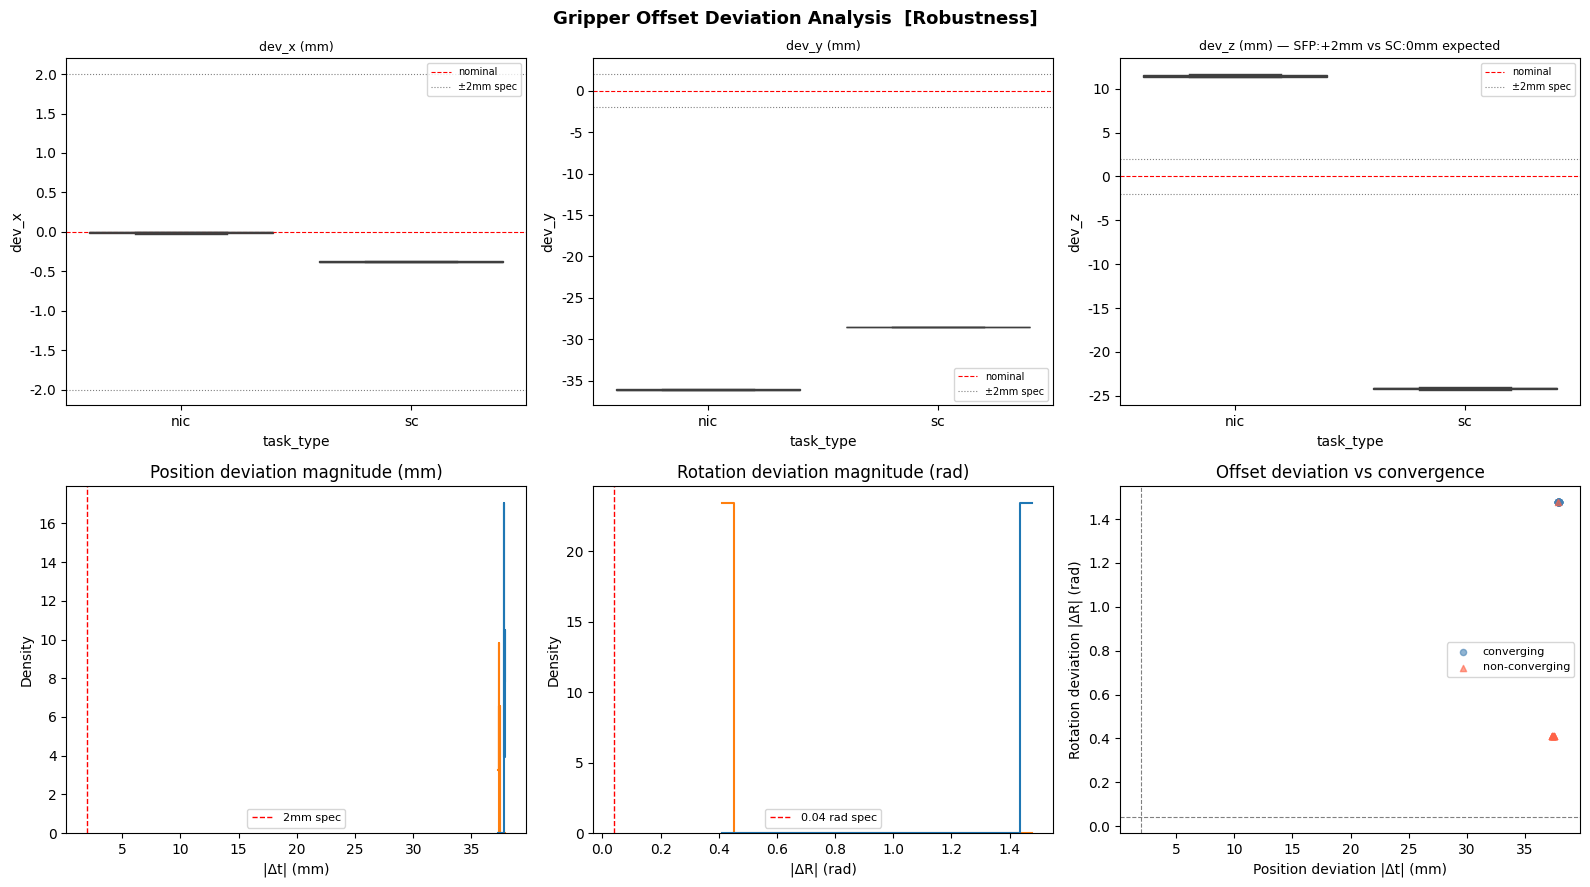

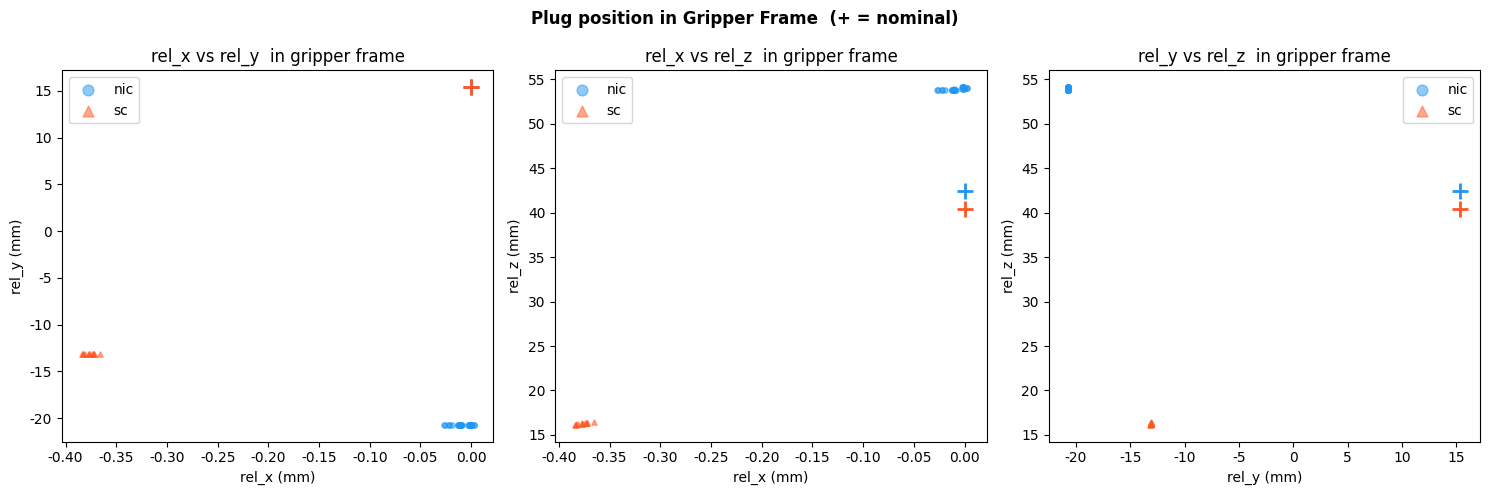


=== Gripper Offset Deviation Summary ===
[NIC]
  Position dev std : 0.034 mm  → AUGMENT NEEDED: ±2mm perturbation
  Rotation dev std : 0.0000 rad → AUGMENT NEEDED: ±0.04 rad jitter
[SC]
  Position dev std : 0.060 mm  → AUGMENT NEEDED: ±2mm perturbation
  Rotation dev std : 0.0000 rad → AUGMENT NEEDED: ±0.04 rad jitter

Corr(position_deviation, converges): +0.933
  → unexpected — check data

[NIC] rel_z mean=53.922mm  (nominal=40.245mm,  diff=+13.677mm)

[SC] rel_z mean=16.281mm  (nominal=40.045mm,  diff=-23.764mm)


In [23]:
# ── 10-1: 에피소드 시작 시 플러그-in-그리퍼 상대 포즈 계산 ──────────────────
from scipy.spatial.transform import Rotation as R

# 명목 gripper_offset (task_type별)
NOMINAL = {
    'nic': {'t': np.array([0.0, 0.015385, 0.04245]),
            'r': R.from_euler('xyz', [0.4432, -0.4838, 1.3303])},
    'sc':  {'t': np.array([0.0, 0.015385, 0.04045]),
            'r': R.from_euler('xyz', [0.4432, -0.4838, 1.3303])},
}

def quat_to_rot(row, prefix):
    """DataFrame row에서 quaternion(w,x,y,z) → scipy Rotation."""
    return R.from_quat([
        row[f'{prefix}_qx'], row[f'{prefix}_qy'],
        row[f'{prefix}_qz'], row[f'{prefix}_qw'],   # scipy: (x,y,z,w)
    ])

offset_rows = []
required_cols = ['plug_qw','plug_qx','plug_qy','plug_qz',
                 'grip_qw','grip_qx','grip_qy','grip_qz']

for sess, sg in steps_df.groupby('session'):
    # approach 첫 step
    app = sg[sg['phase'] == 'approach'].sort_values('step')
    if len(app) == 0:
        continue
    row0 = app.iloc[0]

    # NaN 체크
    if row0[required_cols].isna().any():
        continue

    try:
        R_grip  = quat_to_rot(row0, 'grip')
        R_plug  = quat_to_rot(row0, 'plug')
        t_grip  = np.array([row0['grip_x'], row0['grip_y'], row0['grip_z']])
        t_plug  = np.array([row0['plug_x'], row0['plug_y'], row0['plug_z']])

        # plug in gripper frame
        t_rel   = R_grip.inv().apply(t_plug - t_grip)  # translation in gripper frame
        R_rel   = R_grip.inv() * R_plug                 # rotation in gripper frame
        euler_rel = R_rel.as_euler('xyz')               # roll, pitch, yaw

        task = row0['task_type']
        nom  = NOMINAL.get(task, NOMINAL['nic'])

        t_dev   = t_rel - nom['t']                      # position deviation
        R_dev   = R_rel * nom['r'].inv()                # rotation deviation
        angle_dev = R_dev.magnitude()                   # scalar rotation deviation (rad)

        # 수렴 판정: insert 후반부 |tip_error| 감소 여부
        ins = sg[sg['phase'] == 'insert'].sort_values('step')
        if len(ins) >= 4:
            err = np.sqrt(ins['tip_x_error']**2 + ins['tip_y_error']**2) * 1000
            mid = len(err) // 2
            converges = float(err.iloc[mid:].mean() < err.iloc[:mid].mean())
            steps_to_half = (err < err.iloc[0]/2).idxmax() if (err < err.iloc[0]/2).any() else np.nan
        else:
            converges, steps_to_half = np.nan, np.nan

        d_start = float(np.linalg.norm(
            np.array([row0['plug_x']-row0['port_x'],
                      row0['plug_y']-row0['port_y'],
                      row0['plug_z']-row0['port_z']])
        )) * 1000  # mm

        offset_rows.append({
            'session':   sess,
            'task_type': task,
            # 그리퍼 프레임 내 절대 포즈
            'rel_x': t_rel[0]*1000, 'rel_y': t_rel[1]*1000, 'rel_z': t_rel[2]*1000,  # mm
            'rel_roll': euler_rel[0], 'rel_pitch': euler_rel[1], 'rel_yaw': euler_rel[2],
            # 명목값 대비 편차
            'dev_x': t_dev[0]*1000, 'dev_y': t_dev[1]*1000, 'dev_z': t_dev[2]*1000,  # mm
            'dev_pos_mm': float(np.linalg.norm(t_dev))*1000,
            'dev_rot_rad': angle_dev,
            # 태스크 난이도 지표
            'd_start_mm': d_start,
            'converges': converges,
        })
    except Exception as e:
        continue

offset_df = pd.DataFrame(offset_rows)
print(f'Episodes with valid gripper offset: {len(offset_df)}')
print(offset_df[['task_type','dev_pos_mm','dev_rot_rad','d_start_mm']].describe().round(4))

# ── 10-2: 위치 편차 분포 ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# (a) XYZ 편차 boxplot by task
for ax, col, label in zip(
    axes[0],
    ['dev_x','dev_y','dev_z'],
    ['dev_x (mm)','dev_y (mm)','dev_z (mm) — SFP:+2mm vs SC:0mm expected']
):
    sns.boxplot(data=offset_df, x='task_type', y=col, ax=ax, showfliers=True)
    ax.axhline(0,  color='red',  lw=0.8, ls='--', label='nominal')
    ax.axhline( 2, color='gray', lw=0.8, ls=':', label='±2mm spec')
    ax.axhline(-2, color='gray', lw=0.8, ls=':')
    ax.set_title(label, fontsize=9)
    ax.legend(fontsize=7)

# (b) 전체 위치 편차 크기 histogram
ax = axes[1, 0]
sns.histplot(data=offset_df, x='dev_pos_mm', hue='task_type', bins=25,
             stat='density', common_norm=False, element='step', fill=False, ax=ax)
ax.axvline(2, color='red', lw=1, ls='--', label='2mm spec')
ax.set_title('Position deviation magnitude (mm)')
ax.set_xlabel('|Δt| (mm)')
ax.legend(fontsize=8)

# (c) 회전 편차 histogram
ax = axes[1, 1]
sns.histplot(data=offset_df, x='dev_rot_rad', hue='task_type', bins=25,
             stat='density', common_norm=False, element='step', fill=False, ax=ax)
ax.axvline(0.04, color='red', lw=1, ls='--', label='0.04 rad spec')
ax.set_title('Rotation deviation magnitude (rad)')
ax.set_xlabel('|ΔR| (rad)')
ax.legend(fontsize=8)

# (d) 초기 편차 크기 vs 수렴 여부 scatter
ax = axes[1, 2]
conv   = offset_df[offset_df['converges'] == 1.0]
noconv = offset_df[offset_df['converges'] == 0.0]
ax.scatter(conv['dev_pos_mm'],   conv['dev_rot_rad'],
           alpha=0.6, s=20, c='steelblue', label='converging')
ax.scatter(noconv['dev_pos_mm'], noconv['dev_rot_rad'],
           alpha=0.6, s=20, c='tomato', marker='^', label='non-converging')
ax.axvline(2,    color='gray', lw=0.8, ls='--')
ax.axhline(0.04, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Position deviation |Δt| (mm)')
ax.set_ylabel('Rotation deviation |ΔR| (rad)')
ax.set_title('Offset deviation vs convergence')
ax.legend(fontsize=8)

plt.suptitle('Gripper Offset Deviation Analysis  [Robustness]',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 10-3: 그리퍼 프레임 내 플러그 위치 scatter (NIC vs SC 분리) ─────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [('rel_x','rel_y'), ('rel_x','rel_z'), ('rel_y','rel_z')]
for ax, (cx, cy) in zip(axes, pairs):
    for task, color, m in [('nic','#2196F3','o'), ('sc','#FF5722','^')]:
        sub = offset_df[offset_df['task_type'] == task]
        ax.scatter(sub[cx], sub[cy], alpha=0.5, s=15, c=color, marker=m, label=task)
    # 명목값 cross
    for task, color in [('nic','#2196F3'), ('sc','#FF5722')]:
        nom = NOMINAL[task]
        xi = ['rel_x','rel_y','rel_z'].index(cx)
        yi = ['rel_x','rel_y','rel_z'].index(cy)
        ax.scatter([nom['t'][xi]*1000], [nom['t'][yi]*1000],
                   c=color, s=120, marker='+', linewidths=2, zorder=5)
    ax.set_xlabel(f'{cx} (mm)'); ax.set_ylabel(f'{cy} (mm)')
    ax.set_title(f'{cx} vs {cy}  in gripper frame')
    ax.legend(markerscale=2)

plt.suptitle('Plug position in Gripper Frame  (+ = nominal)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 10-4: 요약 판정 ───────────────────────────────────────────────────────
print('\n=== Gripper Offset Deviation Summary ===')
for task in ['nic', 'sc']:
    sub = offset_df[offset_df['task_type'] == task]
    if len(sub) == 0: continue
    pos_std = sub['dev_pos_mm'].std()
    rot_std = sub['dev_rot_rad'].std()
    pos_flag = 'OK (covers 2mm spec)' if pos_std > 2 else \
               ('caution' if pos_std > 1 else 'AUGMENT NEEDED: ±2mm perturbation')
    rot_flag = 'OK (covers 0.04 rad spec)' if rot_std > 0.04 else \
               ('caution' if rot_std > 0.02 else 'AUGMENT NEEDED: ±0.04 rad jitter')
    print(f'[{task.upper()}]')
    print(f'  Position dev std : {pos_std:.3f} mm  → {pos_flag}')
    print(f'  Rotation dev std : {rot_std:.4f} rad → {rot_flag}')

# 편차-수렴 상관
valid = offset_df.dropna(subset=['converges','dev_pos_mm'])
if len(valid) > 5:
    corr = valid['dev_pos_mm'].corr(valid['converges'])
    print(f'\nCorr(position_deviation, converges): {corr:+.3f}')
    interp = 'larger deviation → harder (expected)' if corr < -0.1 else \
             ('no clear effect' if abs(corr) < 0.1 else 'unexpected — check data')
    print(f'  → {interp}')

# SFP vs SC z-offset 분리 확인
for task, nom_z in [('nic', 40.245), ('sc', 40.045)]:
    sub = offset_df[offset_df['task_type'] == task]
    if len(sub):
        print(f'\n[{task.upper()}] rel_z mean={sub["rel_z"].mean():.3f}mm  '
              f'(nominal={nom_z:.3f}mm,  diff={sub["rel_z"].mean()-nom_z:+.3f}mm)')
